# Stock Price Forecasting — Multi-Model Benchmark

This notebook benchmarks every major forecasting approach on the same set of
stocks, using the **same train/test split** so results are directly comparable:

- **Baseline:** ARIMA (`auto_arima`)
- **Classical / Boosted ML (tabular, lag-feature based):** Linear Regression,
  Ridge Regression, SVR, LightGBM, CatBoost, XGBoost
- **Deep Learning (sequence-window based):** SimpleRNN, LSTM, GRU

For every (stock, model) pair we report **RMSE, MAE, MAPE, R²** and plot
actual vs. predicted closing price on the held-out test period. A final
section consolidates everything into a single comparison table and chart,
and reports the best model per stock.

**Data note:** Prices are pulled live with `yfinance`. If Yahoo Finance is
unreachable (e.g. restricted network), the notebook automatically falls back
to a synthetic price series per ticker so every cell below still runs
end-to-end — when you run this with normal internet access, real data is
used automatically with no changes needed.

## 1. Imports & Configuration

In [25]:
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

import pmdarima as pm

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, SimpleRNN, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import yfinance as yf

np.random.seed(42)
tf.random.set_seed(42)

In [6]:
STOCKS = {
    "Oracle": "ORCL",
    "ICICI": "ICICIBANK.NS",
    "Britannia": "BRITANNIA.NS",
    "Maruti": "MARUTI.NS",
    "AbbottIndia": "ABBOTINDIA.NS",
}

START_DATE = "2021-01-01"
END_DATE = "2025-12-31"
SPLIT_DATE = "2025-07-01"     # before -> train, on/after -> test

ROLL_WINDOW = 30              # rolling mean/std window (trend & volatility features)
SEQ_WINDOW = 60                # lookback window for the deep learning models
LAG_FEATURES = [1, 2, 3, 5, 10, 20]

EPOCHS = 30
BATCH_SIZE = 32
PATIENCE = 5

OUTPUT_DIR = "outputs"
PLOT_DIR = os.path.join(OUTPUT_DIR, "plots")
RESULT_DIR = os.path.join(OUTPUT_DIR, "results")
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

ALL_RESULTS = []  # collects one row per (stock, model) -> final comparison table

## 2. Data Acquisition

Downloads daily closing prices for each ticker. Falls back to a synthetic
geometric-Brownian-motion series only if the live download fails.

In [7]:
def generate_synthetic_series(ticker, start, end, seed=0):
    """Fallback series, used only if a live download is not possible."""
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(start=start, end=end)
    n = len(dates)
    mu, sigma = 0.0004, 0.018
    returns = rng.normal(mu, sigma, n)
    price = 100 * np.exp(np.cumsum(returns))
    return pd.DataFrame({"Close": price}, index=dates)


def download_stock_data(stocks, start, end):
    data = {}
    for name, ticker in stocks.items():
        print(f"Downloading data for {name} ({ticker})")
        try:
            raw = yf.download(ticker, start=start, end=end, progress=False)
            if raw is None or raw.empty:
                raise ValueError("empty dataframe returned")
            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = raw.columns.get_level_values(0)
            df = raw[["Close"]].dropna()
            df.columns = ["Close"]
            print(f"  -> {df.shape[0]} rows loaded from Yahoo Finance")
        except Exception as e:
            print(f"  -> live download unavailable ({e})")
            print("  -> using synthetic fallback series so the notebook can still run")
            df = generate_synthetic_series(ticker, start, end, seed=abs(hash(ticker)) % 10_000)
        data[name] = df
    print("\nAll stock series ready.\n")
    return data

  -> 1254 rows loaded from Yahoo Finance
  -> 1235 rows loaded from Yahoo Finance
  -> 1235 rows loaded from Yahoo Finance
  -> 1235 rows loaded from Yahoo Finance
  -> 1235 rows loaded from Yahoo Finance

All stock series ready.



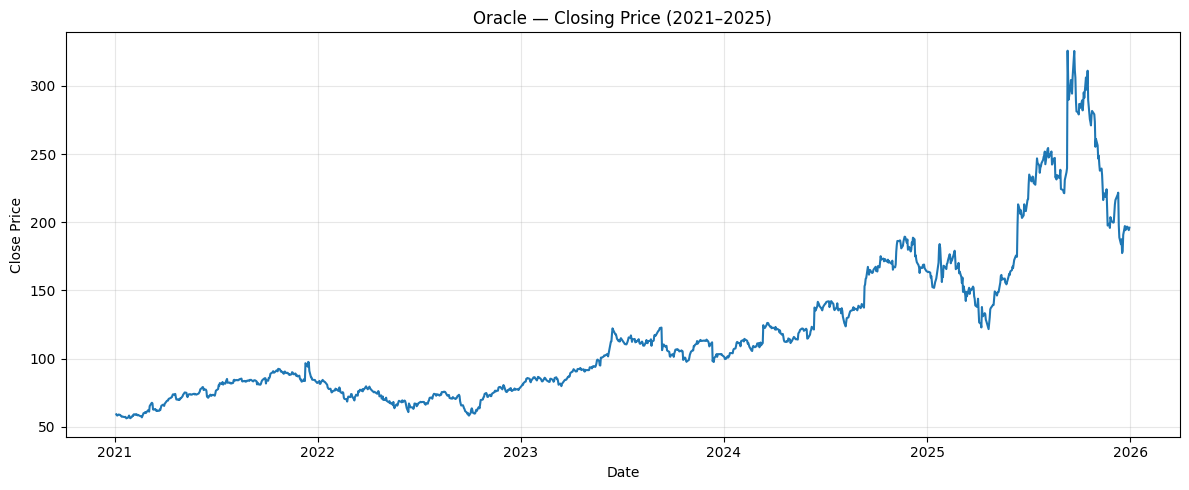

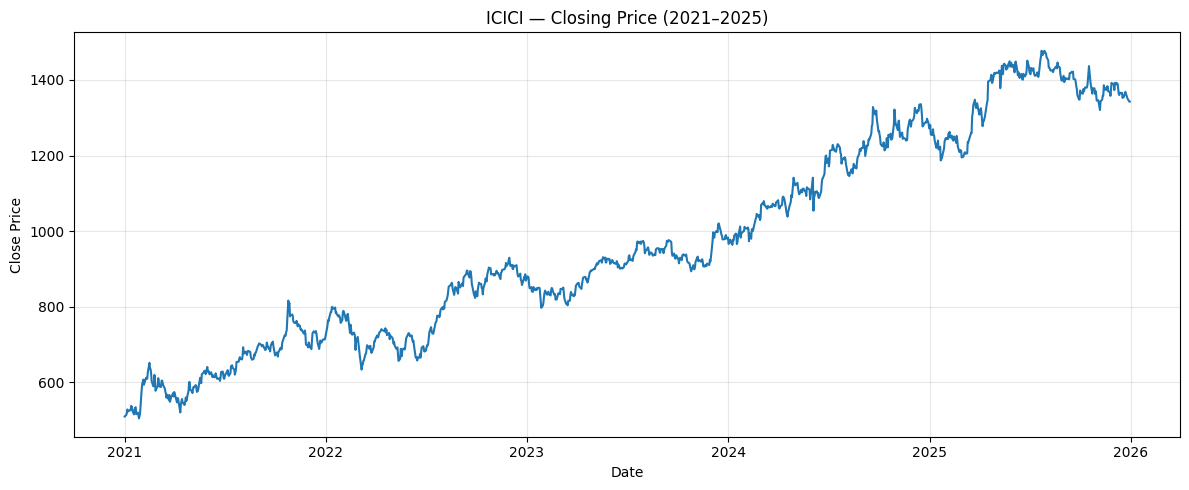

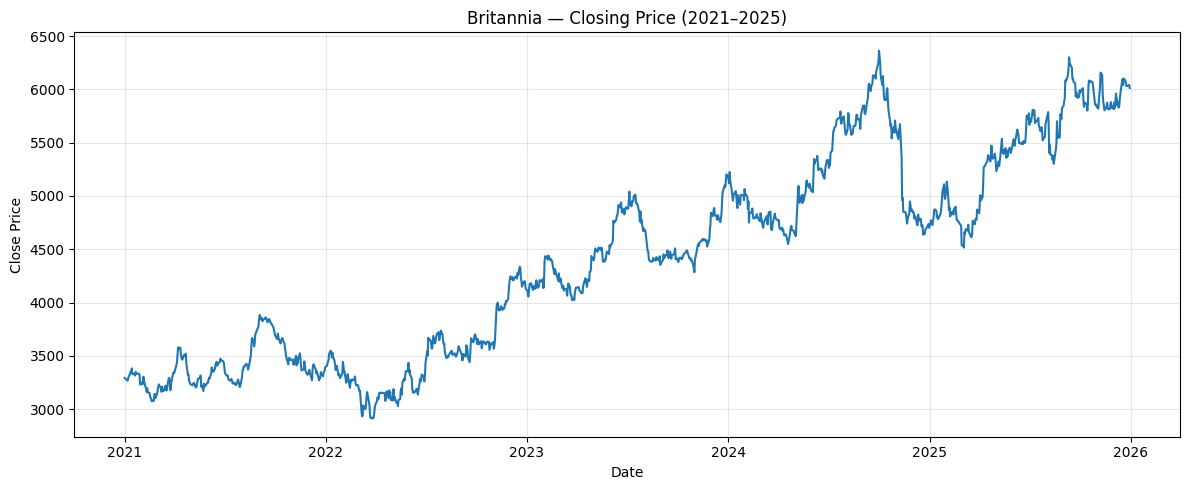

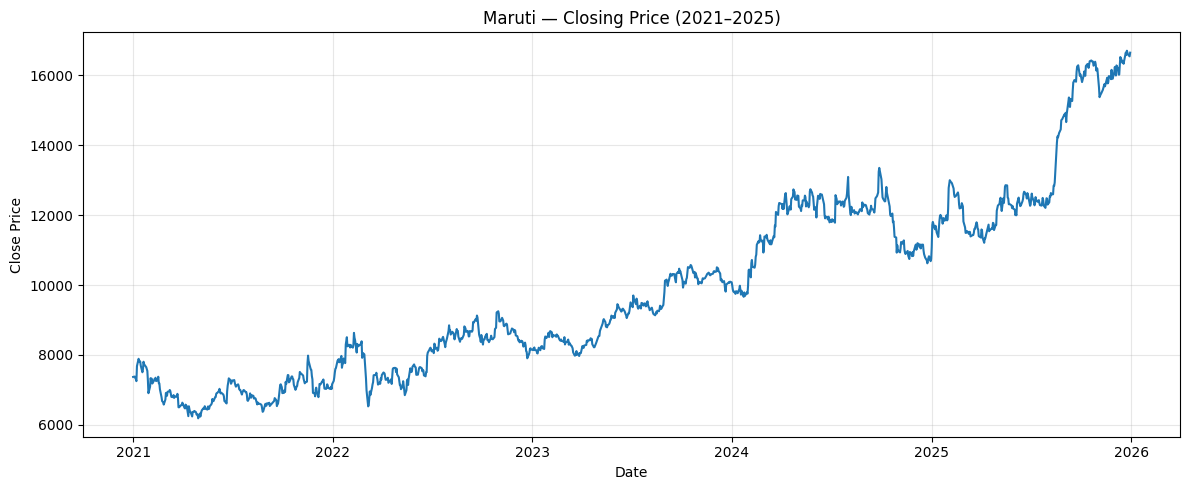

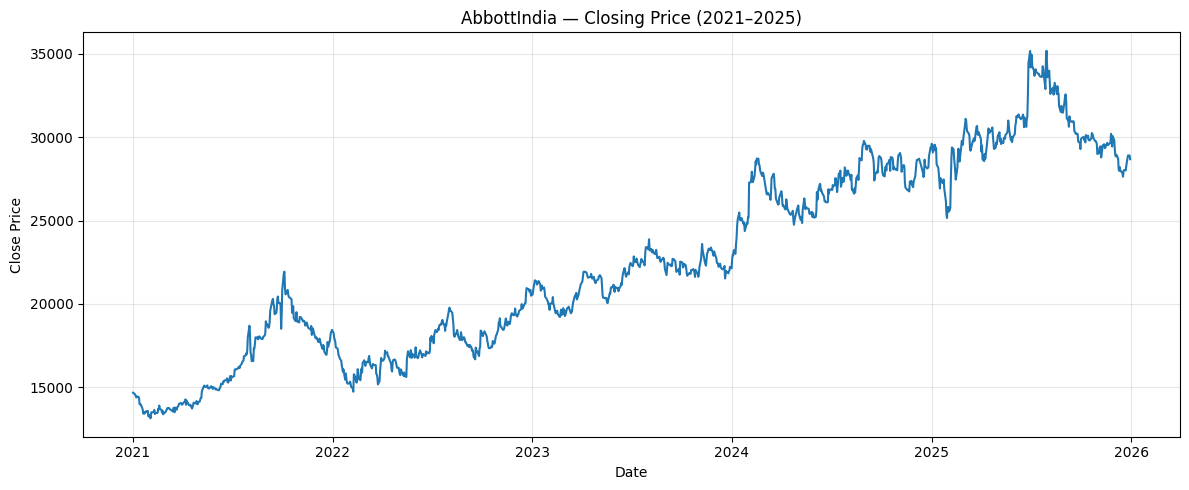

In [8]:
raw_data = download_stock_data(STOCKS, START_DATE, END_DATE)

for name, df in raw_data.items():
    plt.figure(figsize=(12, 5))
    plt.plot(df.index, df["Close"])
    plt.title(f"{name} — Closing Price ({START_DATE[:4]}–{END_DATE[:4]})")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{name}_closing_price.png"), dpi=110)
    plt.show()

## 3. Feature Engineering, Splitting & Scaling Helpers

In [9]:
def add_rolling_features(df, window=ROLL_WINDOW):
    df = df.copy()
    df["Rolling_Mean"] = df["Close"].rolling(window=window).mean()
    df["Rolling_Std"] = df["Close"].rolling(window=window).std()
    df = df.bfill().ffill()
    return df


def split_by_date(df, split_date=SPLIT_DATE):
    df = df.sort_index()
    train = df[df.index < split_date]
    test = df[df.index >= split_date]
    return train, test


def build_tabular_features(df, lags=LAG_FEATURES):
    """Lag + rolling features used by every tabular ML model (no leakage)."""
    df_feat = df[["Close"]].copy()
    for lag in lags:
        df_feat[f"lag_{lag}"] = df_feat["Close"].shift(lag)
    df_feat["roll_mean_10"] = df_feat["Close"].rolling(10).mean().shift(1)
    df_feat["roll_std_10"] = df_feat["Close"].rolling(10).std().shift(1)
    df_feat = df_feat.dropna()

    feature_cols = [c for c in df_feat.columns if c != "Close"]
    X = df_feat[feature_cols]
    y = df_feat["Close"]
    return X, y


def create_sequences(data, window=SEQ_WINDOW):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i - window:i])
        y.append(data[i, 0])  # Close is column 0
    return np.array(X), np.array(y)


def prepare_sequence_data(df, split_date=SPLIT_DATE, window=SEQ_WINDOW):
    df_feat = add_rolling_features(df)
    train_df, test_df = split_by_date(df_feat, split_date)

    feat_cols = ["Close", "Rolling_Mean", "Rolling_Std"]
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_df[feat_cols])
    test_scaled = scaler.transform(test_df[feat_cols])

    X_train, y_train = create_sequences(train_scaled, window)
    X_test, y_test = create_sequences(test_scaled, window)
    return X_train, y_train, X_test, y_test, scaler


def inverse_close(scaled_values, scaler, n_features=3):
    arr = np.zeros((len(scaled_values), n_features))
    arr[:, 0] = np.asarray(scaled_values).reshape(-1)
    return scaler.inverse_transform(arr)[:, 0]

## 4. Metrics & Plotting Helpers

In [10]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-8, y_true))) * 100
    r2 = r2_score(y_true, y_pred)
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2}


def plot_predictions(stock_name, model_name, actual, predicted):
    plt.figure(figsize=(12, 5))
    plt.plot(actual, label="Actual", linewidth=2)
    plt.plot(predicted, label=f"{model_name} Prediction", linestyle="--")
    plt.title(f"{stock_name} — {model_name}: Actual vs Predicted")
    plt.xlabel("Trading Days (Test Period)")
    plt.ylabel("Close Price")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    fname = os.path.join(PLOT_DIR, f"{stock_name}_{model_name.replace(' ', '_')}.png")
    plt.savefig(fname, dpi=110)
    plt.show()
    return fname


def record_result(stock, model, metrics):
    row = {"Stock": stock, "Model": model}
    row.update(metrics)
    ALL_RESULTS.append(row)

## 5. ARIMA Baseline

A classical statistical baseline (`auto_arima`) fit on the raw closing-price
series for each stock — every other model should be benchmarked against this.

In [11]:
def run_arima_baseline(name, train_df, test_df):
    print(f"\n[ARIMA baseline] {name}")
    train_close = train_df["Close"].dropna()
    test_close = test_df["Close"].dropna()
    try:
        model = pm.auto_arima(
            train_close,
            seasonal=False,
            stepwise=True,
            suppress_warnings=True,
            error_action="ignore",
        )
        preds = np.asarray(model.predict(n_periods=len(test_close))).reshape(-1)

        metrics = compute_metrics(test_close.values, preds)
        plot_predictions(name, "ARIMA (baseline)", test_close.values, preds)
        record_result(name, "ARIMA (baseline)", metrics)
        print(f"  order={model.order}  RMSE={metrics['RMSE']:.3f}  MAE={metrics['MAE']:.3f}  "
              f"MAPE={metrics['MAPE']:.2f}%  R2={metrics['R2']:.3f}")
    except Exception as e:
        print(f"  ARIMA failed for {name}: {e}")

## 6. Classical & Gradient-Boosted ML Models

Linear Regression, Ridge Regression, SVR, LightGBM, CatBoost and XGBoost —
all trained on the same lag + rolling-statistics tabular features, with
features and target both Min-Max scaled (important for Linear/Ridge/SVR;
harmless for the tree-based models).

In [12]:
ML_MODELS = {
    "Linear Regression": lambda: LinearRegression(),
    "Ridge Regression": lambda: Ridge(alpha=1.0, random_state=42),
    "SVR": lambda: SVR(kernel="rbf", C=100, gamma=0.01, epsilon=0.005),
    "LightGBM": lambda: lgb.LGBMRegressor(
        n_estimators=400, learning_rate=0.03, max_depth=-1, random_state=42, verbosity=-1
    ),
    "CatBoost": lambda: CatBoostRegressor(
        iterations=400, learning_rate=0.03, depth=6, random_seed=42, verbose=0
    ),
    "XGBoost": lambda: XGBRegressor(
        n_estimators=400, learning_rate=0.03, max_depth=5, random_state=42, verbosity=0
    ),
    "Random Forest": lambda: RandomForestRegressor(
        n_estimators=200,      # Number of decision trees in the forest
        max_depth=8,           # Prevents trees from growing too deep and overfitting stock noise
        random_state=42,       # Keeps results reproducible
        n_jobs=-1              # Uses all available CPU cores for fast parallel execution
    ),
}


def run_ml_models(name, df):
    X, y = build_tabular_features(df)
    X_train = X[X.index < SPLIT_DATE]
    y_train = y[y.index < SPLIT_DATE]
    X_test = X[X.index >= SPLIT_DATE]
    y_test = y[y.index >= SPLIT_DATE]

    x_scaler = MinMaxScaler()
    X_train_s = x_scaler.fit_transform(X_train)
    X_test_s = x_scaler.transform(X_test)

    y_scaler = MinMaxScaler()
    y_train_s = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()

    for model_name, constructor in ML_MODELS.items():
        print(f"\n[{model_name}] {name}")
        model = constructor()
        model.fit(X_train_s, y_train_s)

        preds_s = model.predict(X_test_s)
        preds = y_scaler.inverse_transform(preds_s.reshape(-1, 1)).flatten()

        metrics = compute_metrics(y_test.values, preds)
        plot_predictions(name, model_name, y_test.values, preds)
        record_result(name, model_name, metrics)
        print(f"  RMSE={metrics['RMSE']:.3f}  MAE={metrics['MAE']:.3f}  "
              f"MAPE={metrics['MAPE']:.2f}%  R2={metrics['R2']:.3f}")

## 7. Deep Learning Models (RNN, LSTM, GRU)

Each uses a 2-layer recurrent stack over a 60-day rolling window of
`[Close, Rolling_Mean, Rolling_Std]` (Min-Max scaled), trained with early
stopping on validation loss.

In [13]:
def build_dl_model(kind, input_shape):
    model = Sequential(name=f"{kind}_model")
    if kind == "RNN":
        model.add(SimpleRNN(64, return_sequences=True, input_shape=input_shape))
        model.add(SimpleRNN(32))
    elif kind == "LSTM":
        model.add(LSTM(64, return_sequences=True, input_shape=input_shape))
        model.add(LSTM(32))
    elif kind == "GRU":
        model.add(GRU(64, return_sequences=True, input_shape=input_shape))
        model.add(GRU(32))
    else:
        raise ValueError(f"Unknown DL model kind: {kind}")

    model.add(Dense(16, activation="relu"))
    model.add(Dropout(0.1))
    model.add(Dense(1))
    model.compile(optimizer="adam", loss="mse")
    return model


def run_dl_models(name, df, epochs=EPOCHS):
    X_train, y_train, X_test, y_test, scaler = prepare_sequence_data(df)
    actual_prices = inverse_close(y_test, scaler)

    for kind in ["RNN", "LSTM", "GRU"]:
        print(f"\n[{kind}] {name}")
        model = build_dl_model(kind, (X_train.shape[1], X_train.shape[2]))
        es = EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)

        model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=BATCH_SIZE,
            validation_data=(X_test, y_test),
            callbacks=[es],
            verbose=0,
        )

        preds_scaled = model.predict(X_test, verbose=0).flatten()
        pred_prices = inverse_close(preds_scaled, scaler)

        metrics = compute_metrics(actual_prices, pred_prices)
        plot_predictions(name, kind, actual_prices, pred_prices)
        record_result(name, kind, metrics)
        print(f"  RMSE={metrics['RMSE']:.3f}  MAE={metrics['MAE']:.3f}  "
              f"MAPE={metrics['MAPE']:.2f}%  R2={metrics['R2']:.3f}")

## 8. Run Every Model for Every Stock

This is the main loop: for each stock, run the ARIMA baseline, all 6 ML
models, and all 3 DL models — each producing metrics + a saved plot.


######################################################################
STOCK: Oracle
######################################################################
Train: 1127 rows (2021-01-04 to 2025-06-30)
Test : 127 rows (2025-07-01 to 2025-12-30)

[ARIMA baseline] Oracle


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


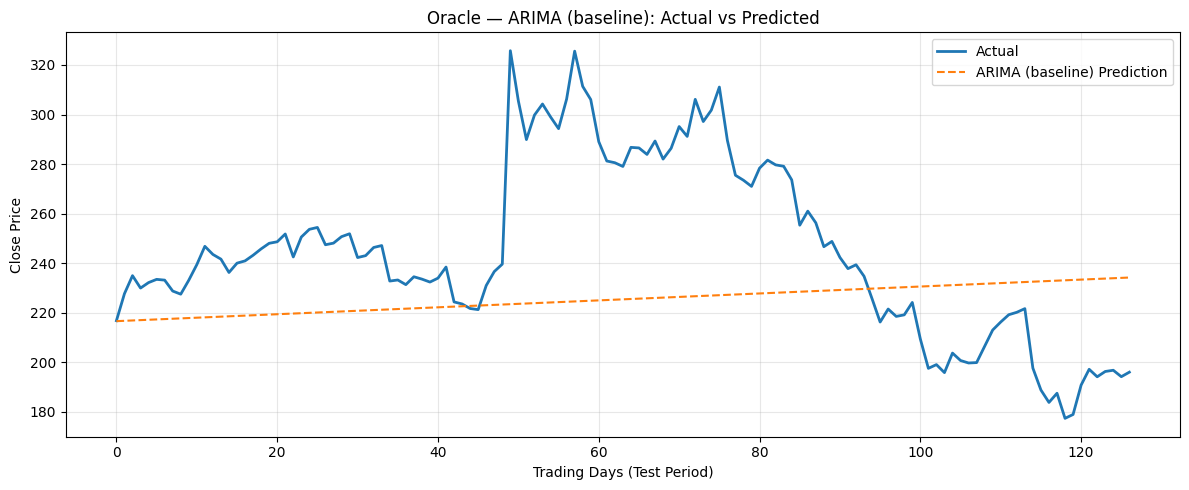

  order=(0, 1, 0)  RMSE=41.995  MAE=34.575  MAPE=13.60%  R2=-0.423

[Linear Regression] Oracle


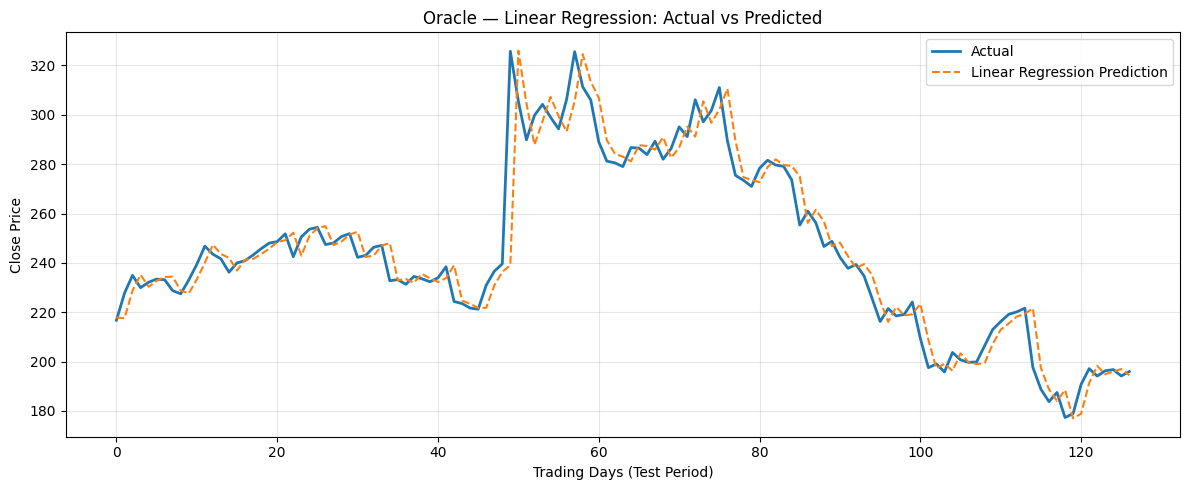

  RMSE=10.790  MAE=6.305  MAPE=2.49%  R2=0.906

[Ridge Regression] Oracle


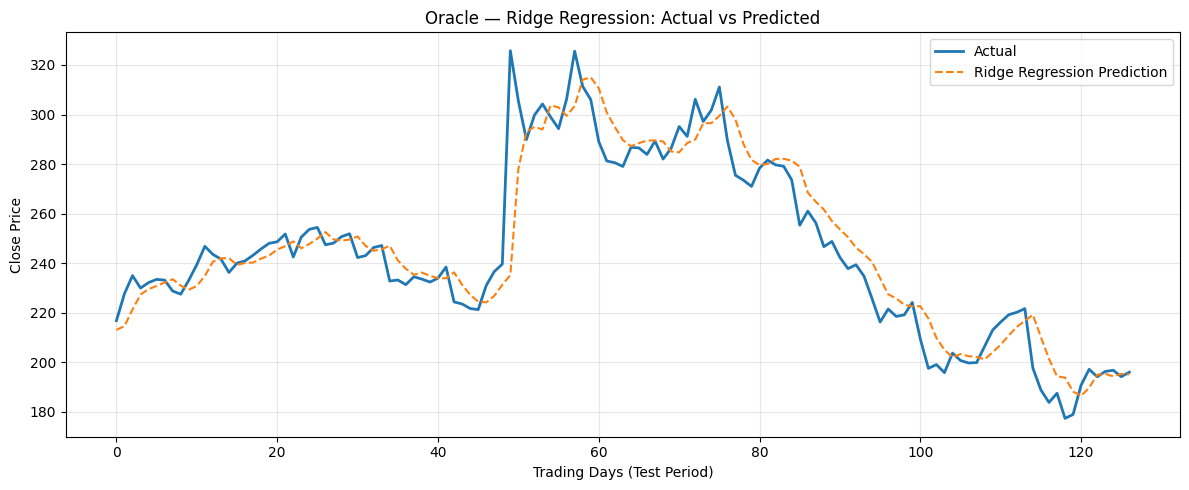

  RMSE=12.364  MAE=7.949  MAPE=3.23%  R2=0.877

[SVR] Oracle


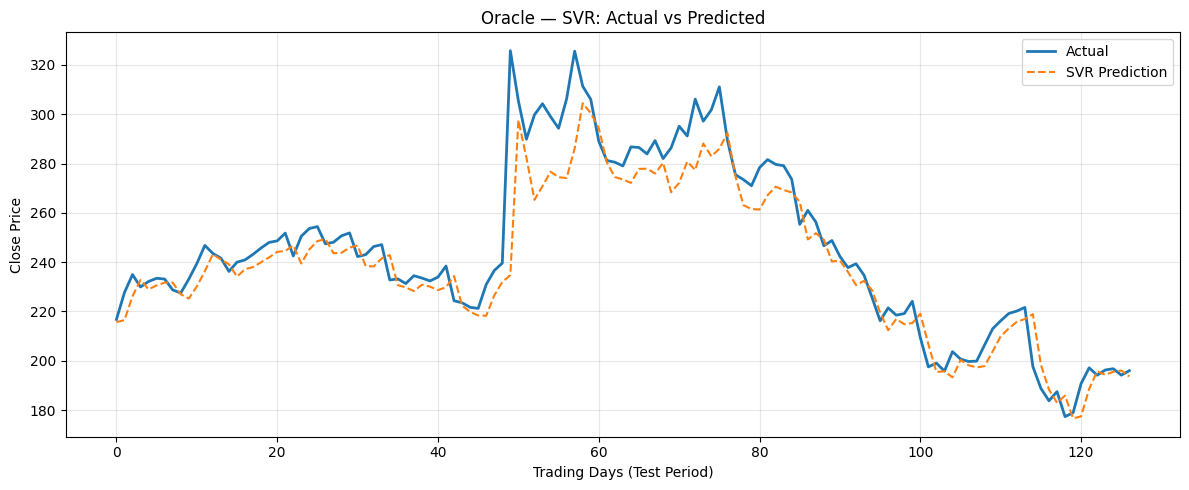

  RMSE=13.362  MAE=8.470  MAPE=3.26%  R2=0.856

[LightGBM] Oracle


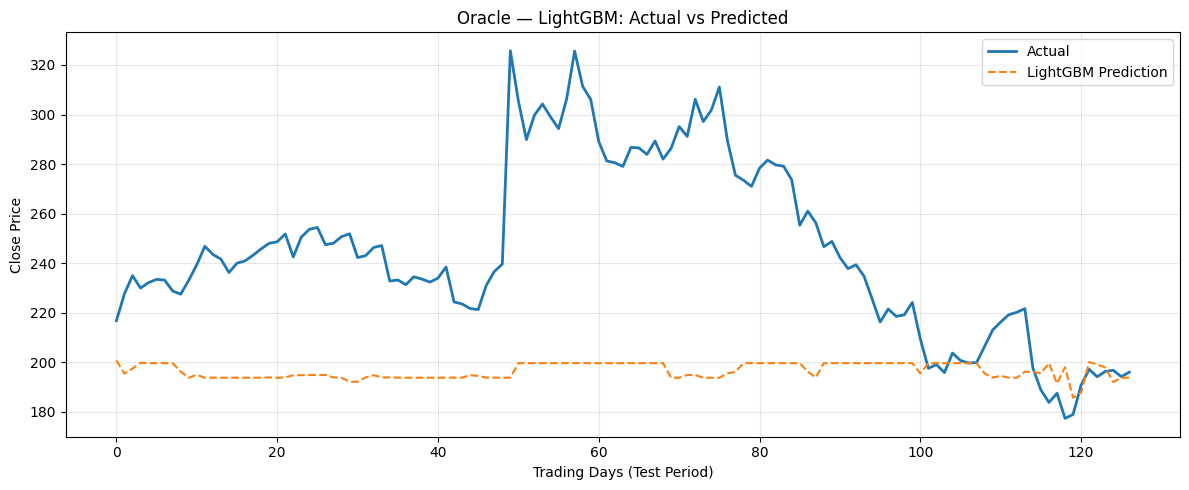

  RMSE=59.624  MAE=49.593  MAPE=18.76%  R2=-1.868

[CatBoost] Oracle


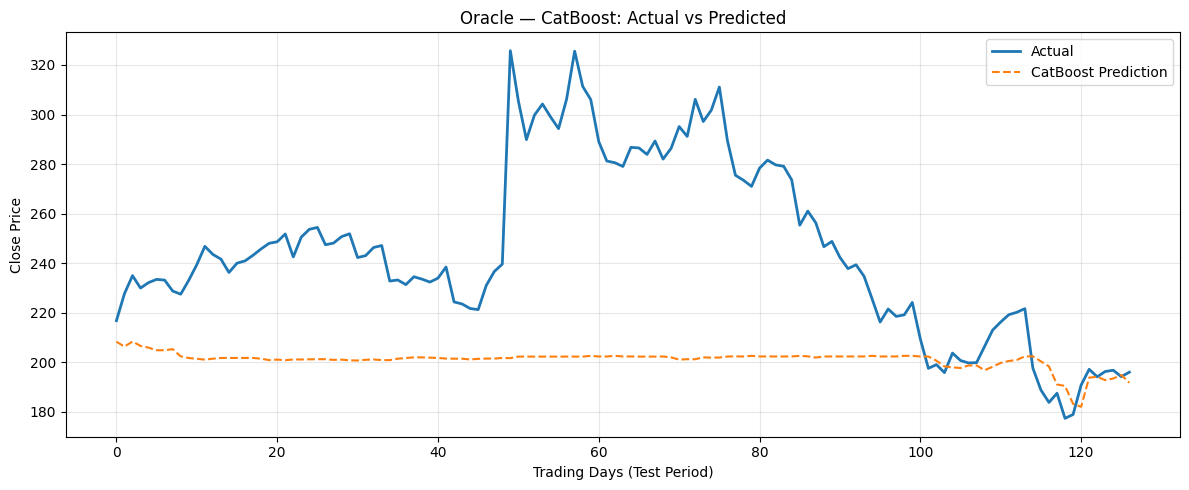

  RMSE=55.418  MAE=44.984  MAPE=16.90%  R2=-1.478

[XGBoost] Oracle


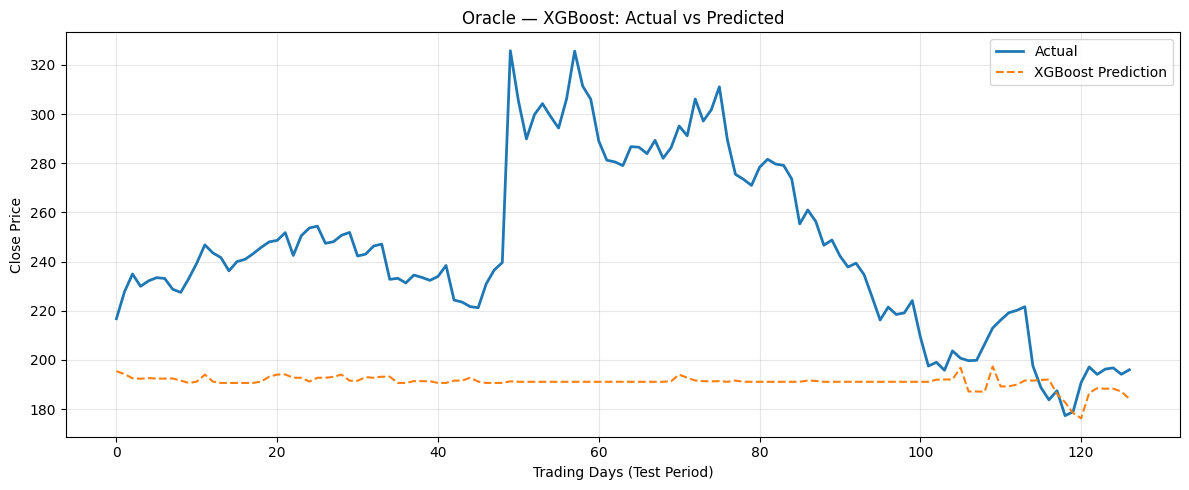

  RMSE=64.036  MAE=54.233  MAPE=20.61%  R2=-2.308

[RNN] Oracle


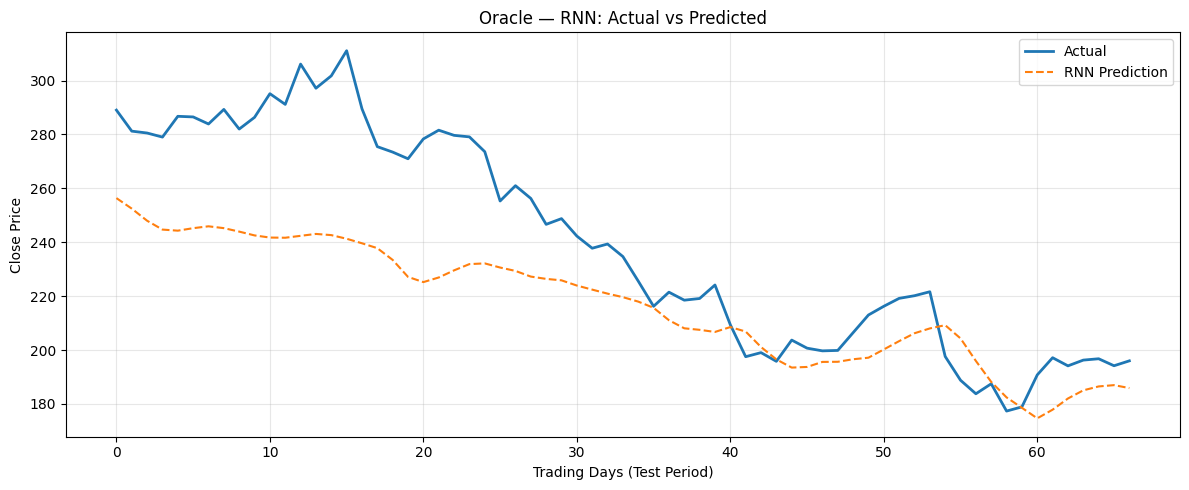

  RMSE=30.713  MAE=24.664  MAPE=9.40%  R2=0.409

[LSTM] Oracle


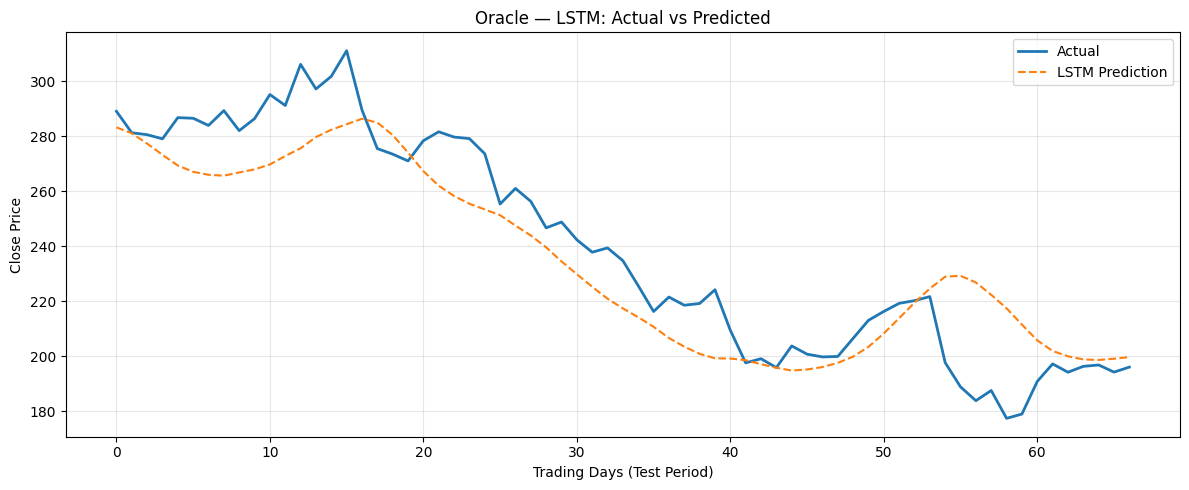

  RMSE=17.233  MAE=13.644  MAPE=5.84%  R2=0.814

[GRU] Oracle


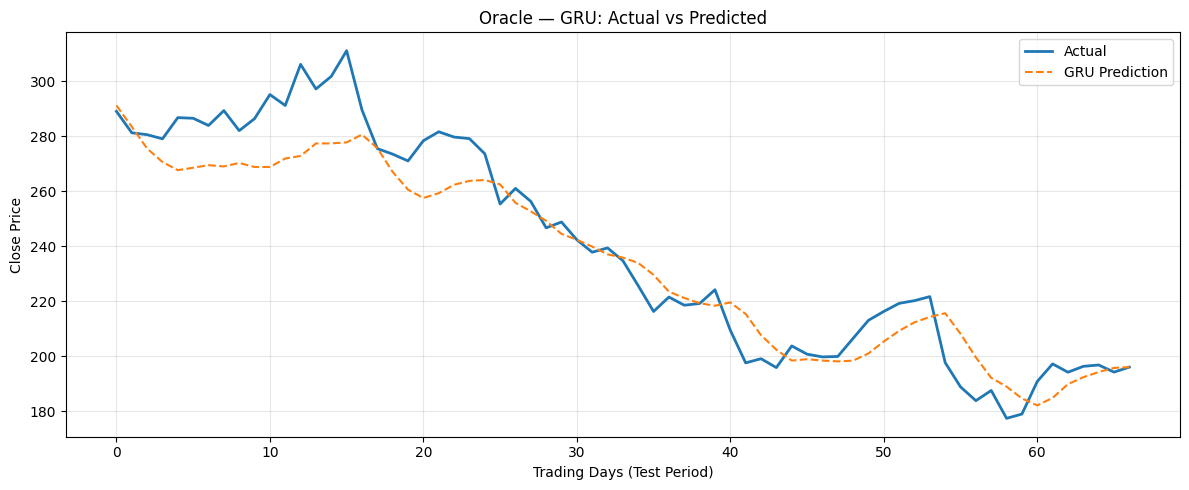

  RMSE=12.737  MAE=9.931  MAPE=4.02%  R2=0.898

######################################################################
STOCK: ICICI
######################################################################
Train: 1110 rows (2021-01-01 to 2025-06-30)
Test : 125 rows (2025-07-01 to 2025-12-30)

[ARIMA baseline] ICICI


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


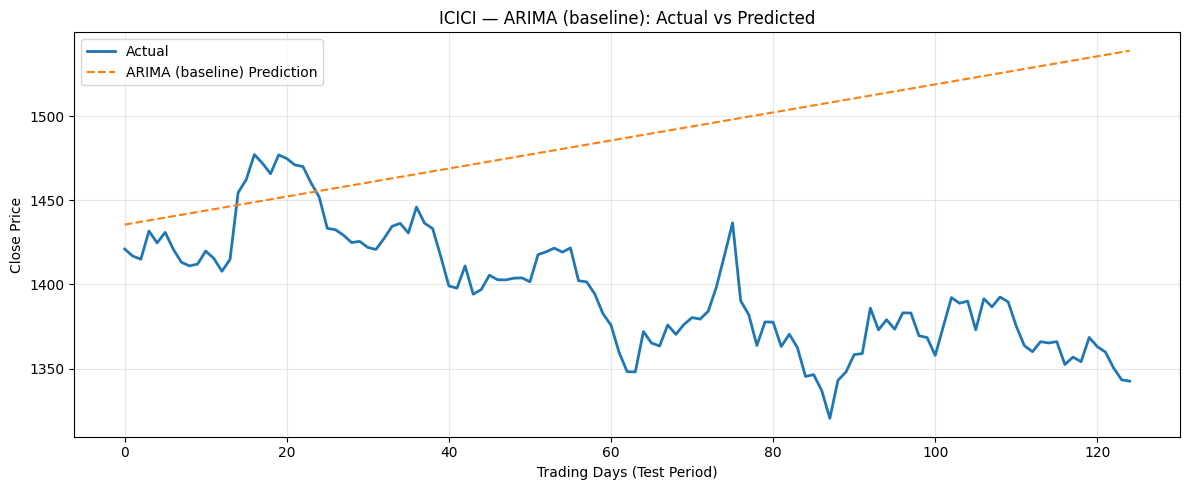

  order=(0, 1, 0)  RMSE=109.509  MAE=93.447  MAPE=6.79%  R2=-8.786

[Linear Regression] ICICI


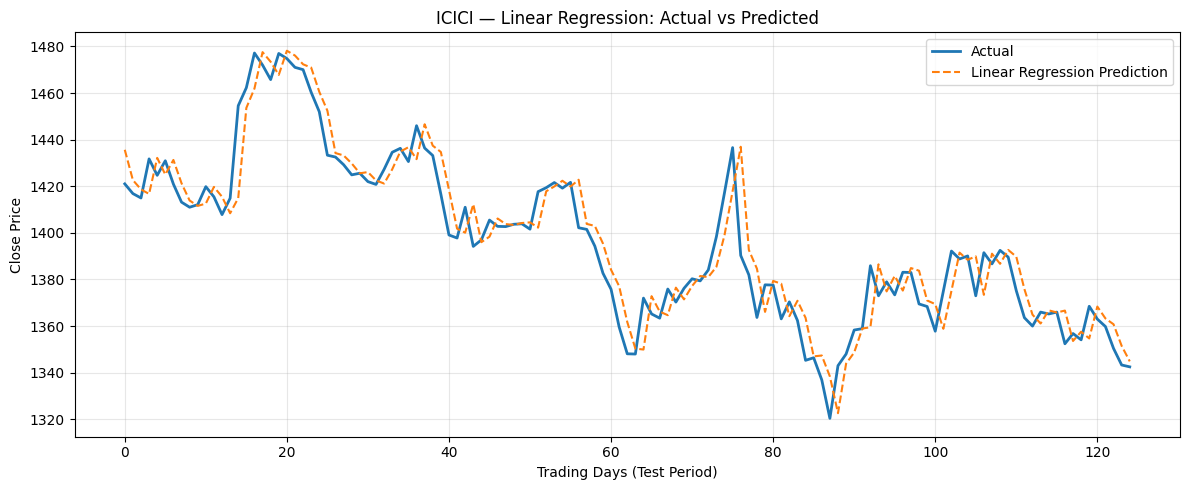

  RMSE=11.524  MAE=8.740  MAPE=0.63%  R2=0.892

[Ridge Regression] ICICI


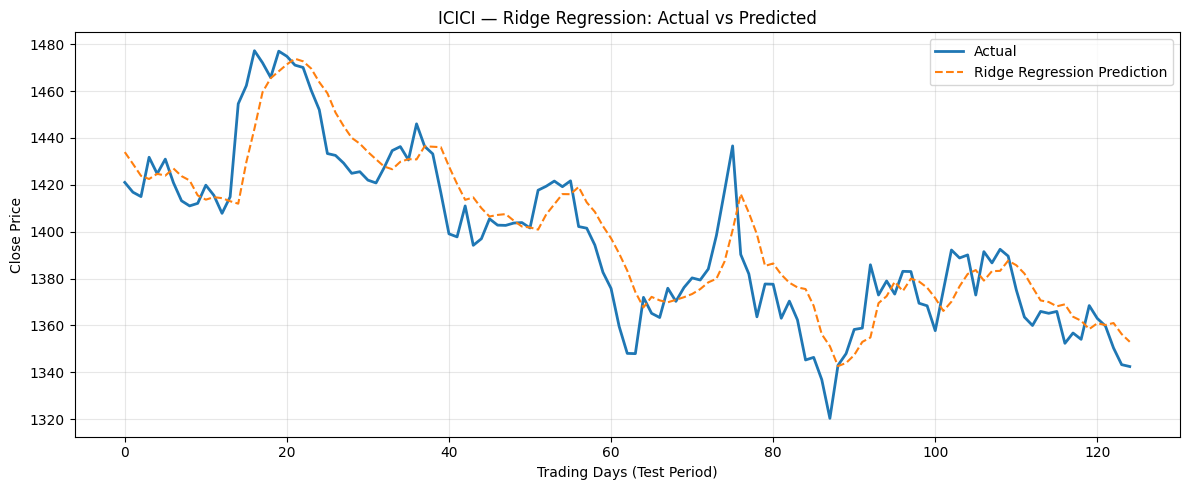

  RMSE=15.000  MAE=11.618  MAPE=0.83%  R2=0.816

[SVR] ICICI


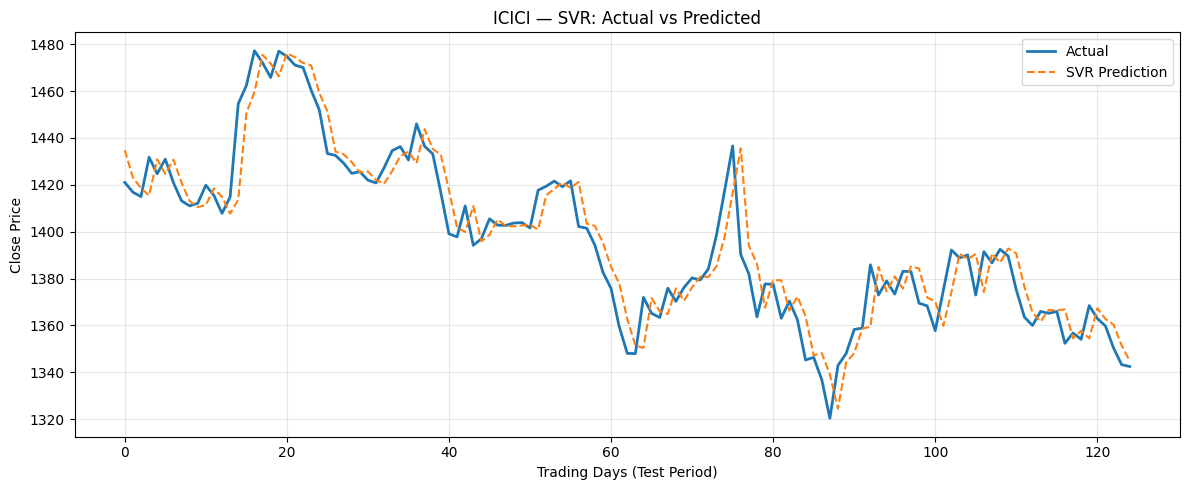

  RMSE=11.580  MAE=8.729  MAPE=0.63%  R2=0.891

[LightGBM] ICICI


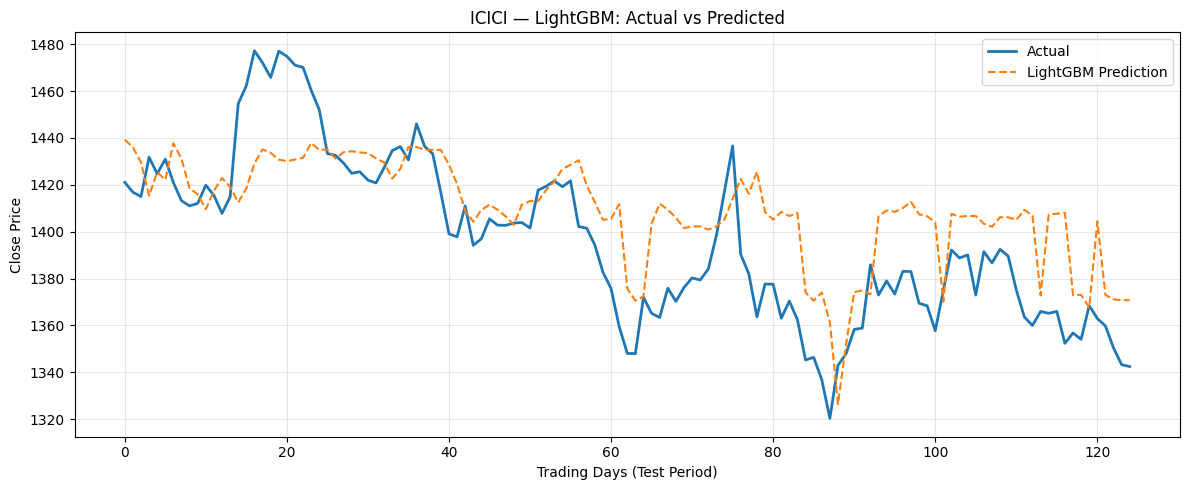

  RMSE=26.118  MAE=21.441  MAPE=1.54%  R2=0.443

[CatBoost] ICICI


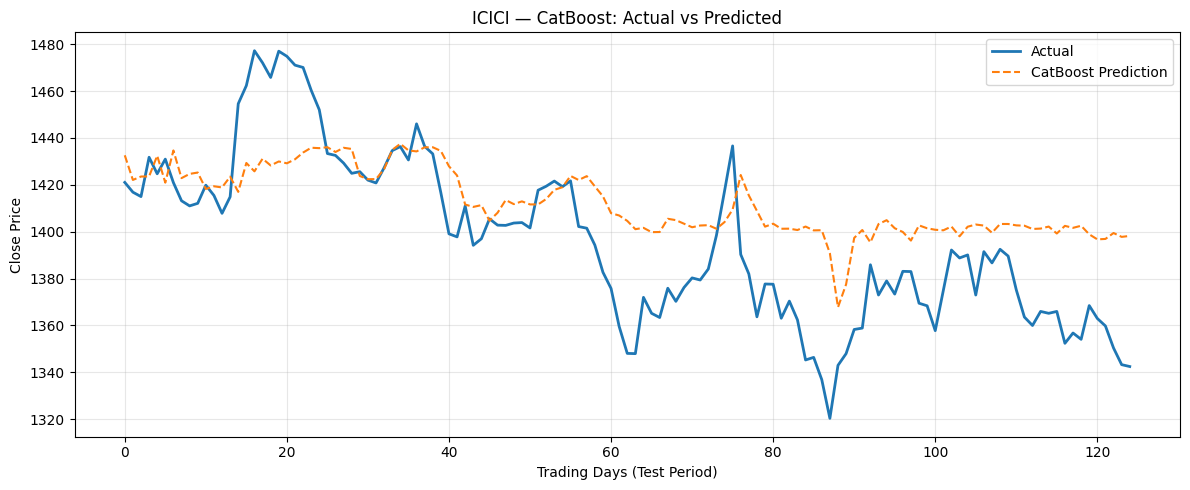

  RMSE=29.182  MAE=23.783  MAPE=1.72%  R2=0.305

[XGBoost] ICICI


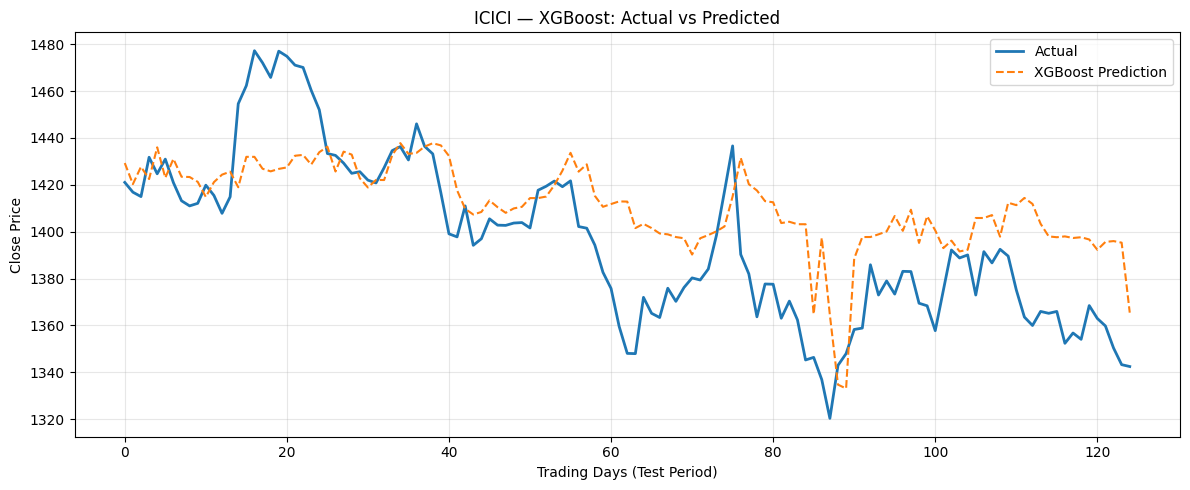

  RMSE=28.377  MAE=23.112  MAPE=1.67%  R2=0.343

[RNN] ICICI


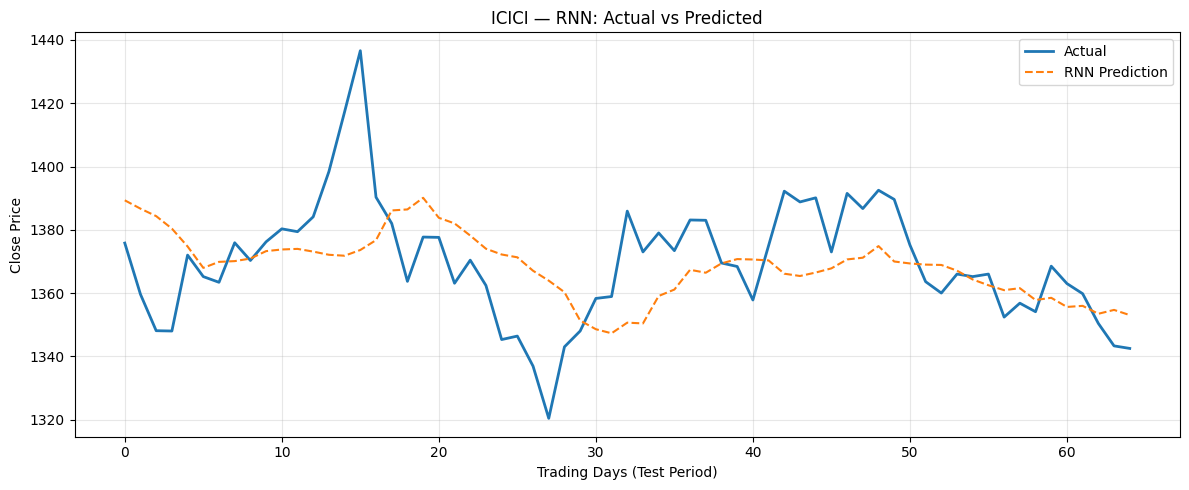

  RMSE=18.946  MAE=14.401  MAPE=1.05%  R2=-0.021

[LSTM] ICICI


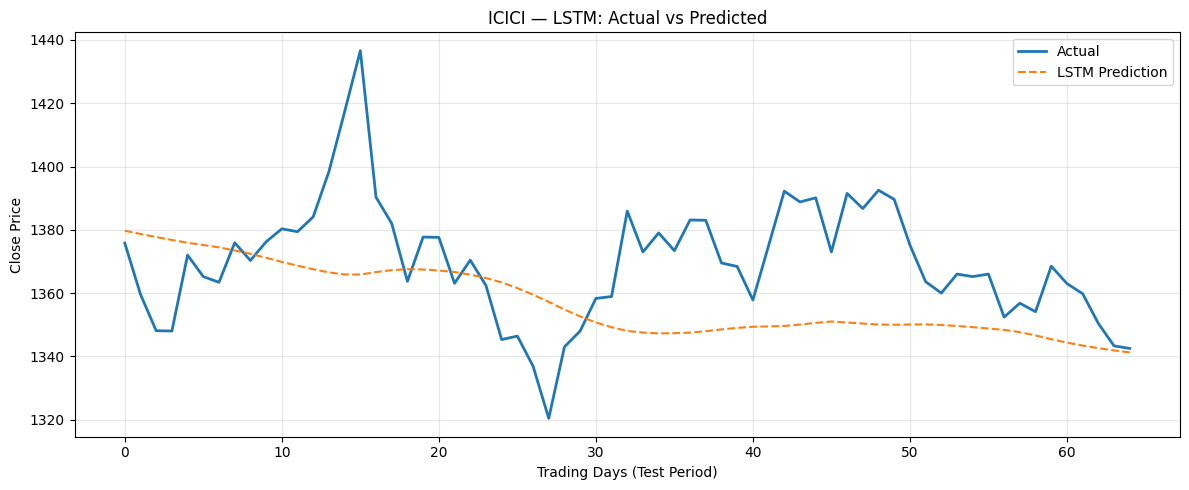

  RMSE=24.160  MAE=19.439  MAPE=1.41%  R2=-0.659

[GRU] ICICI


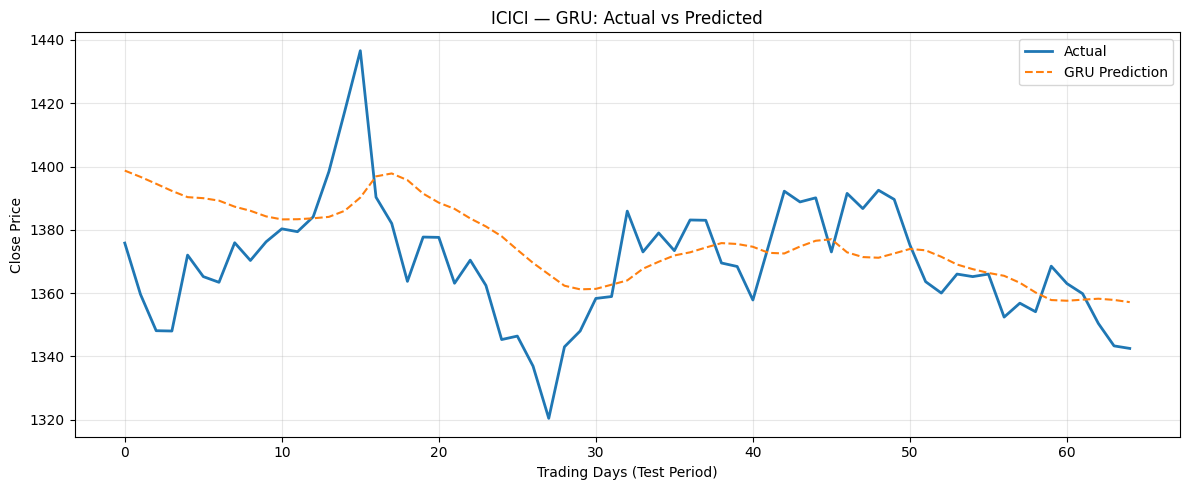

  RMSE=19.236  MAE=15.198  MAPE=1.11%  R2=-0.052

######################################################################
STOCK: Britannia
######################################################################
Train: 1110 rows (2021-01-01 to 2025-06-30)
Test : 125 rows (2025-07-01 to 2025-12-30)

[ARIMA baseline] Britannia


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


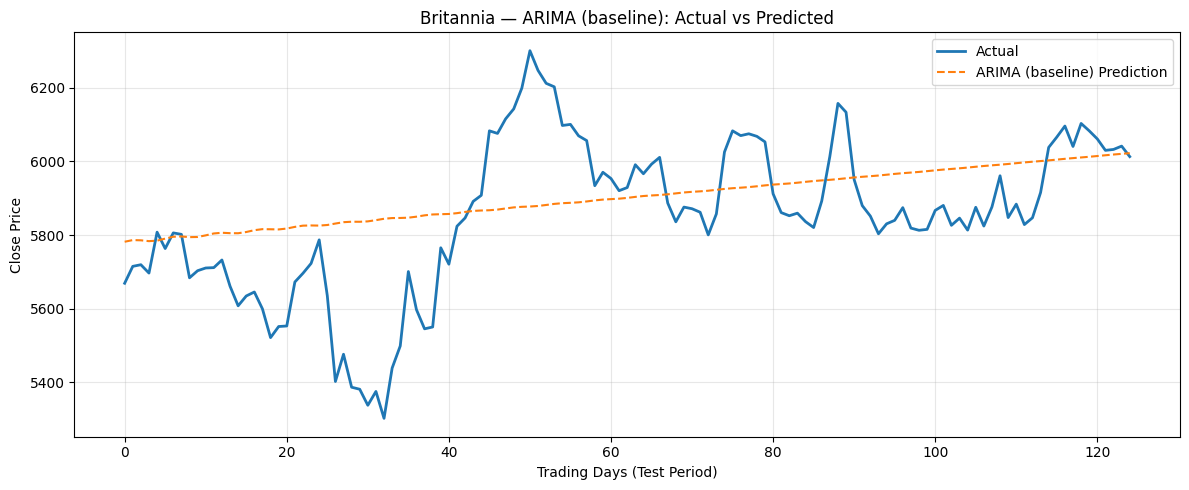

  order=(2, 1, 2)  RMSE=186.685  MAE=145.251  MAPE=2.52%  R2=0.185

[Linear Regression] Britannia


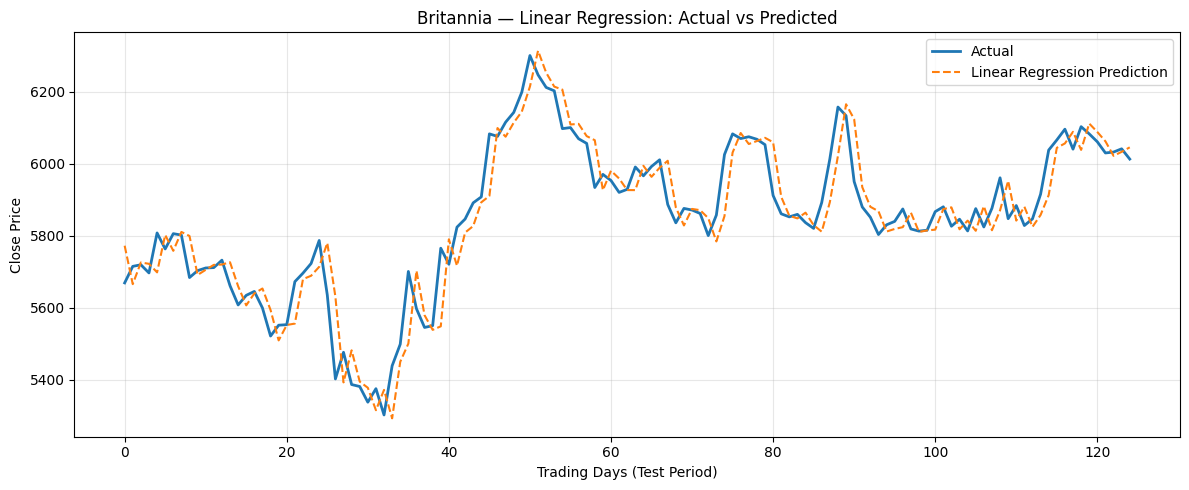

  RMSE=72.587  MAE=54.709  MAPE=0.94%  R2=0.877

[Ridge Regression] Britannia


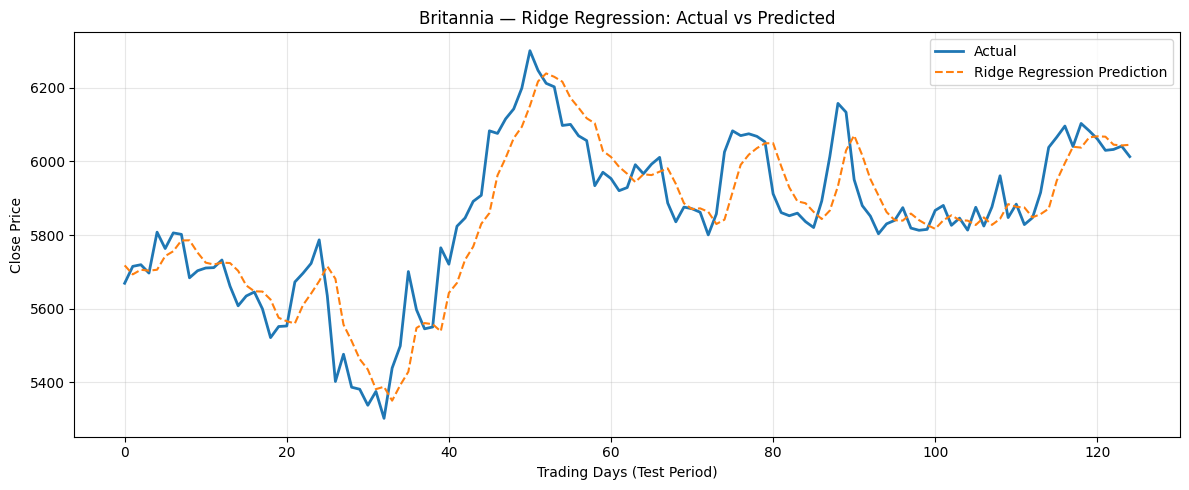

  RMSE=89.657  MAE=68.753  MAPE=1.18%  R2=0.812

[SVR] Britannia


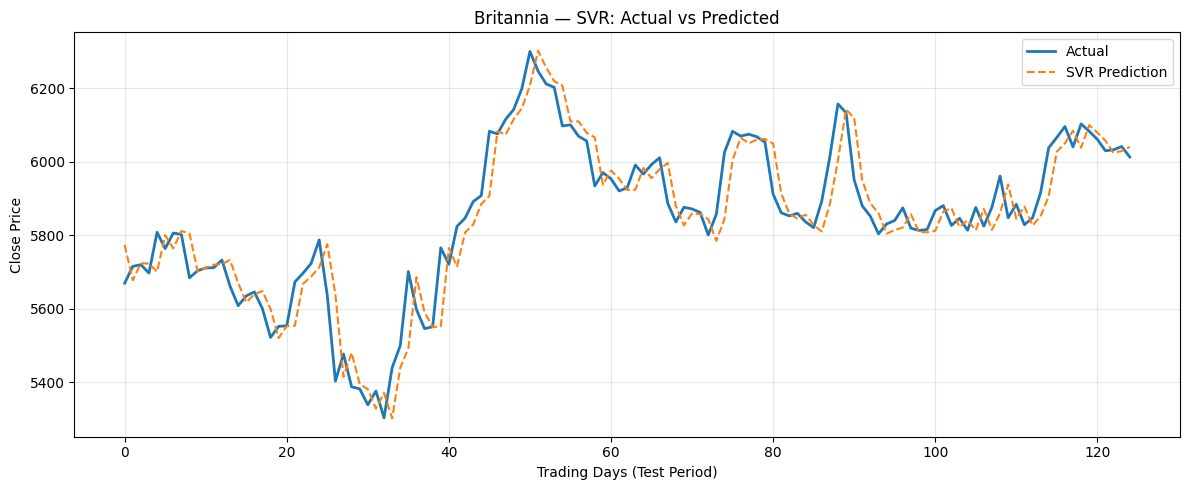

  RMSE=72.852  MAE=54.216  MAPE=0.93%  R2=0.876

[LightGBM] Britannia


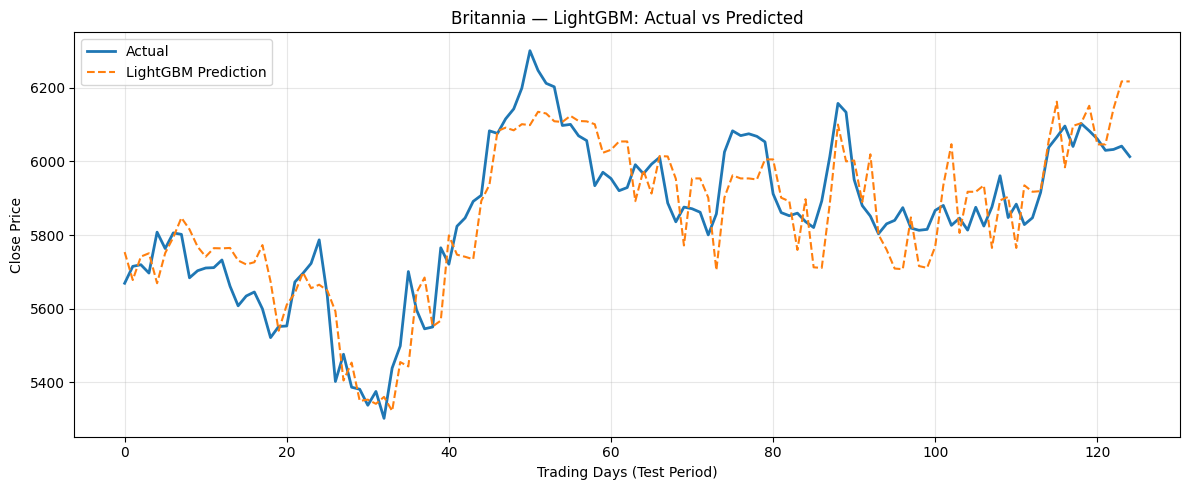

  RMSE=99.592  MAE=83.259  MAPE=1.42%  R2=0.768

[CatBoost] Britannia


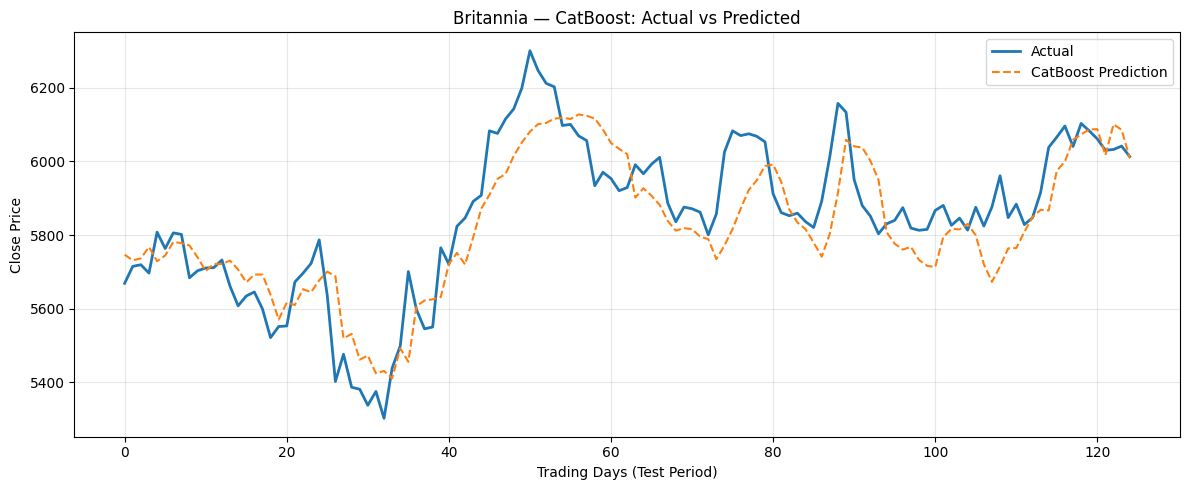

  RMSE=106.677  MAE=85.350  MAPE=1.45%  R2=0.734

[XGBoost] Britannia


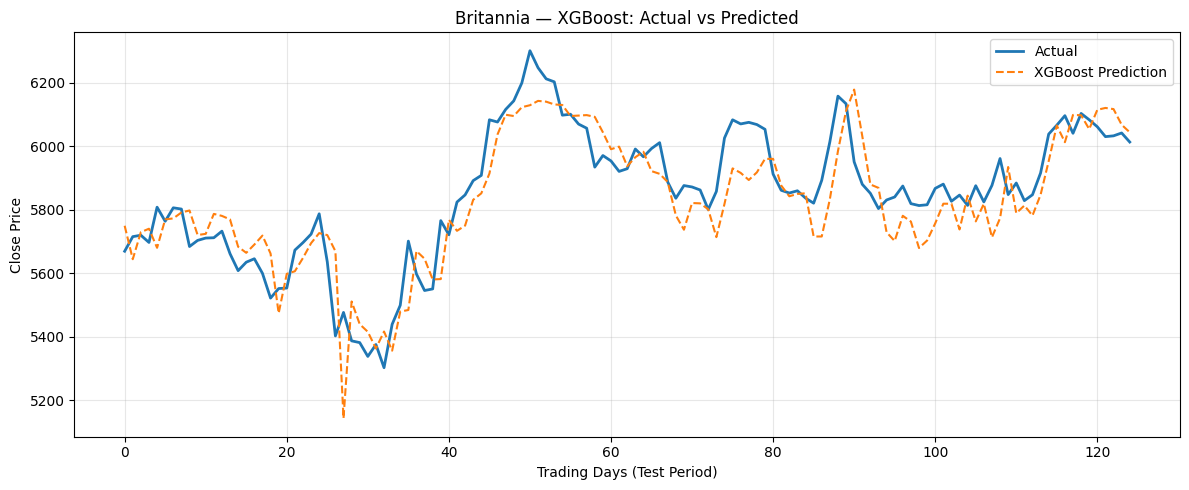

  RMSE=100.379  MAE=79.686  MAPE=1.37%  R2=0.764

[RNN] Britannia


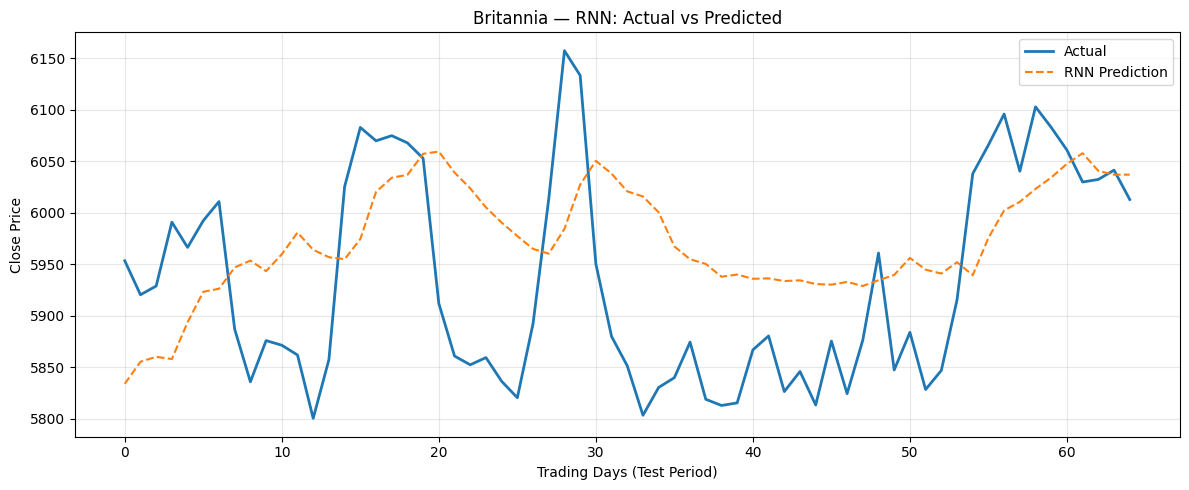

  RMSE=104.210  MAE=92.332  MAPE=1.56%  R2=-0.082

[LSTM] Britannia


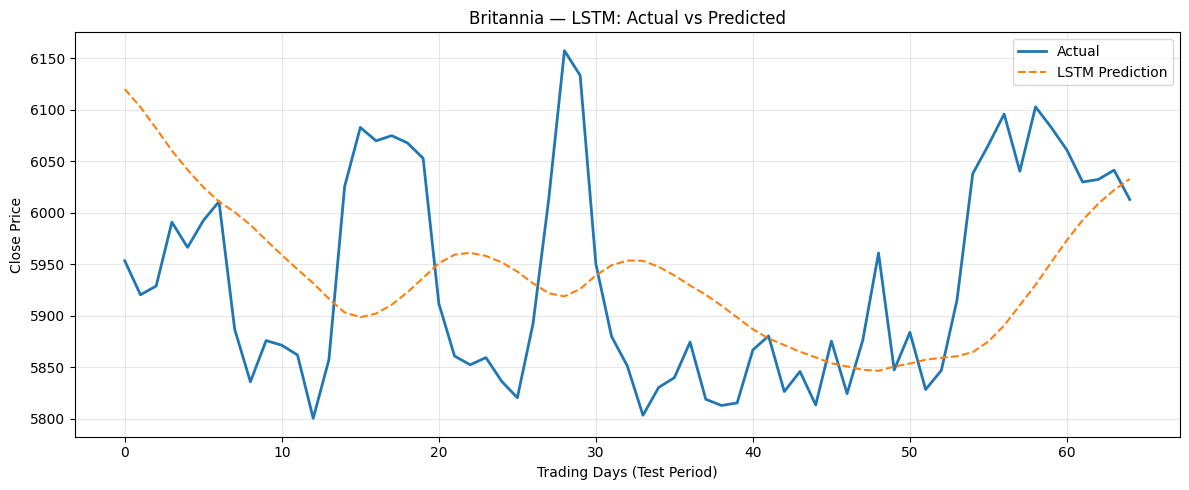

  RMSE=109.919  MAE=92.202  MAPE=1.55%  R2=-0.204

[GRU] Britannia


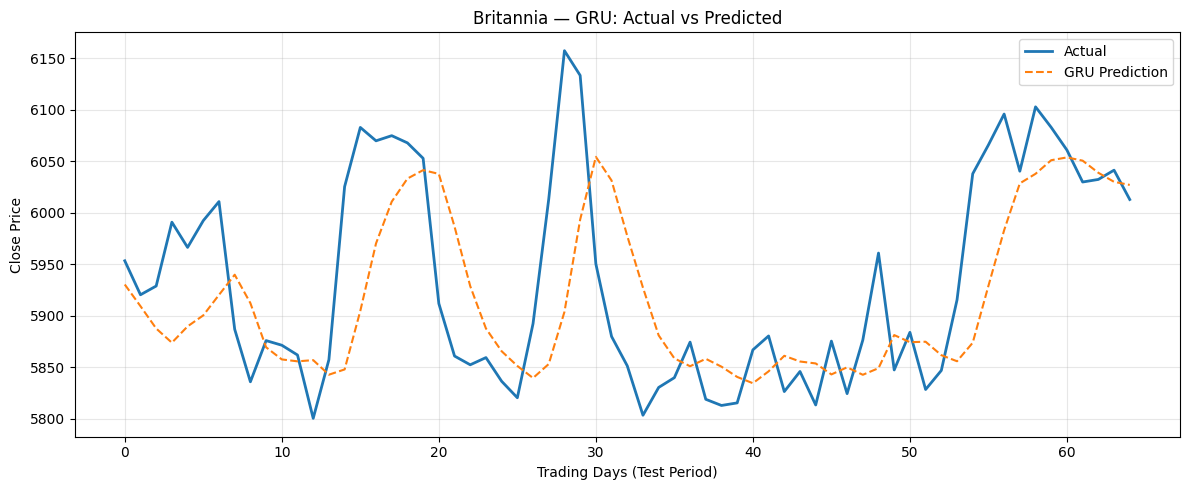

  RMSE=82.859  MAE=62.594  MAPE=1.05%  R2=0.316

######################################################################
STOCK: Maruti
######################################################################
Train: 1110 rows (2021-01-01 to 2025-06-30)
Test : 125 rows (2025-07-01 to 2025-12-30)

[ARIMA baseline] Maruti


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


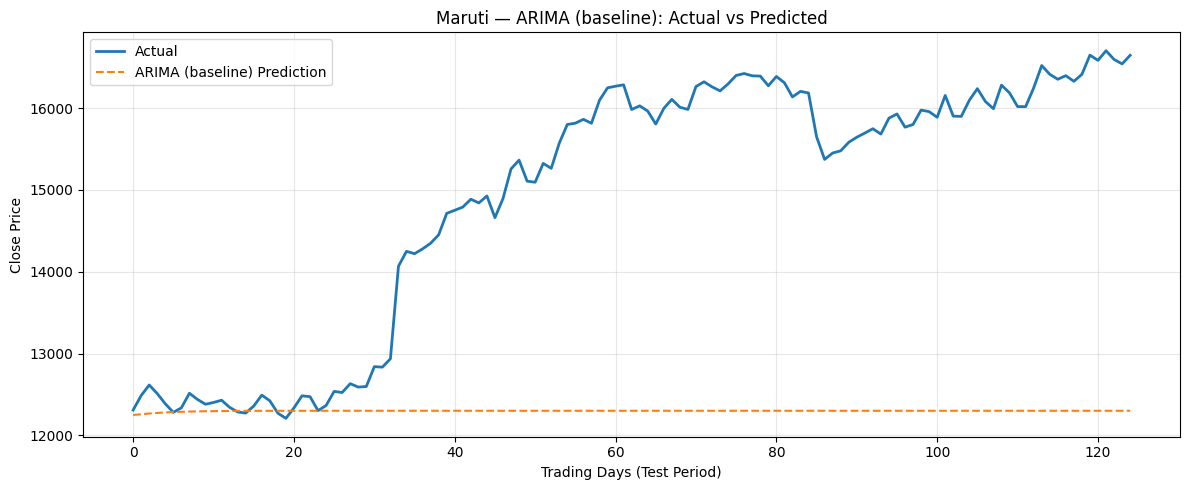

  order=(2, 1, 1)  RMSE=3061.313  MAE=2629.050  MAPE=16.61%  R2=-2.774

[Linear Regression] Maruti


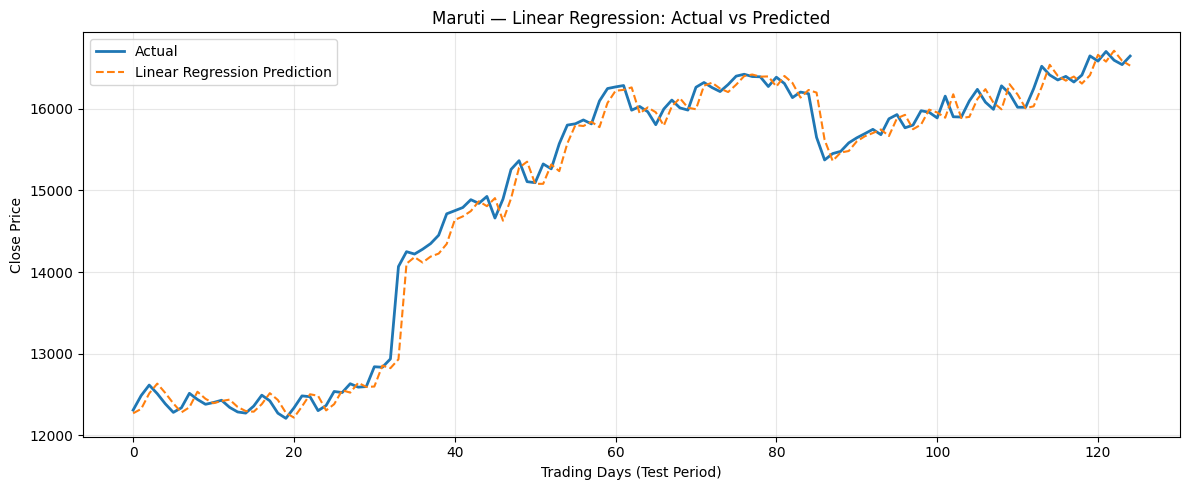

  RMSE=181.977  MAE=127.893  MAPE=0.86%  R2=0.987

[Ridge Regression] Maruti


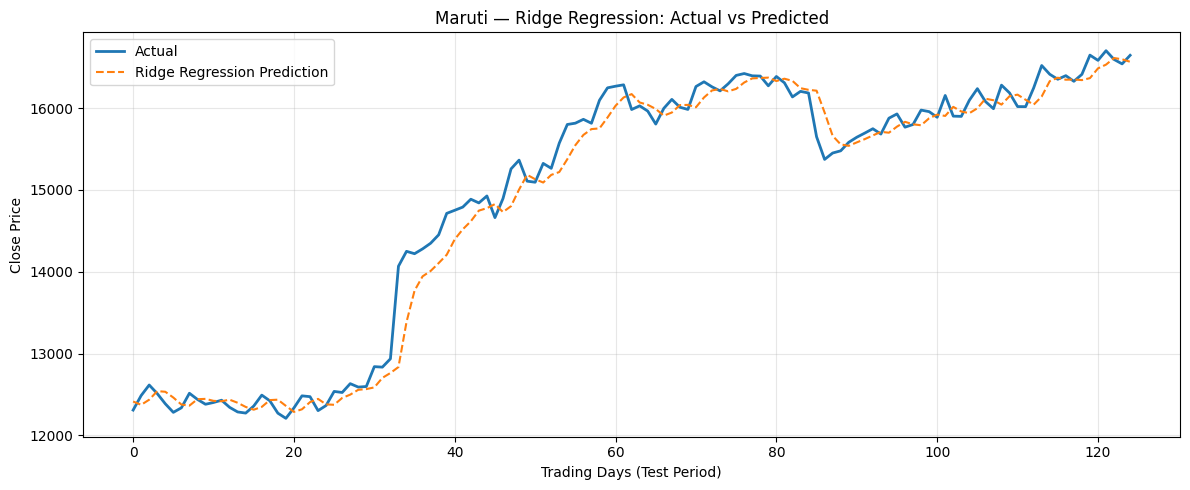

  RMSE=232.848  MAE=160.925  MAPE=1.08%  R2=0.978

[SVR] Maruti


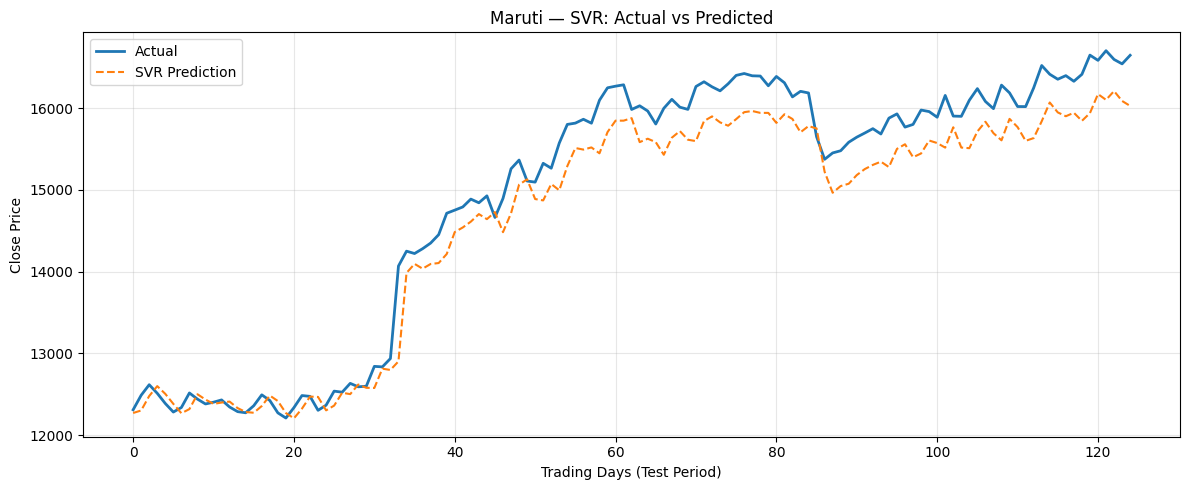

  RMSE=382.629  MAE=323.271  MAPE=2.08%  R2=0.941

[LightGBM] Maruti


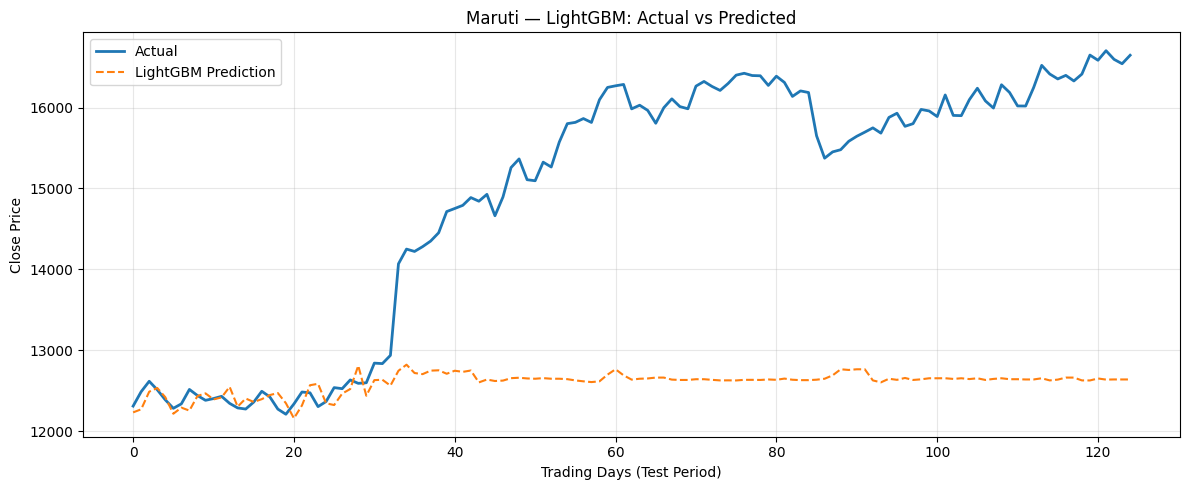

  RMSE=2762.872  MAE=2351.600  MAPE=14.82%  R2=-2.074

[CatBoost] Maruti


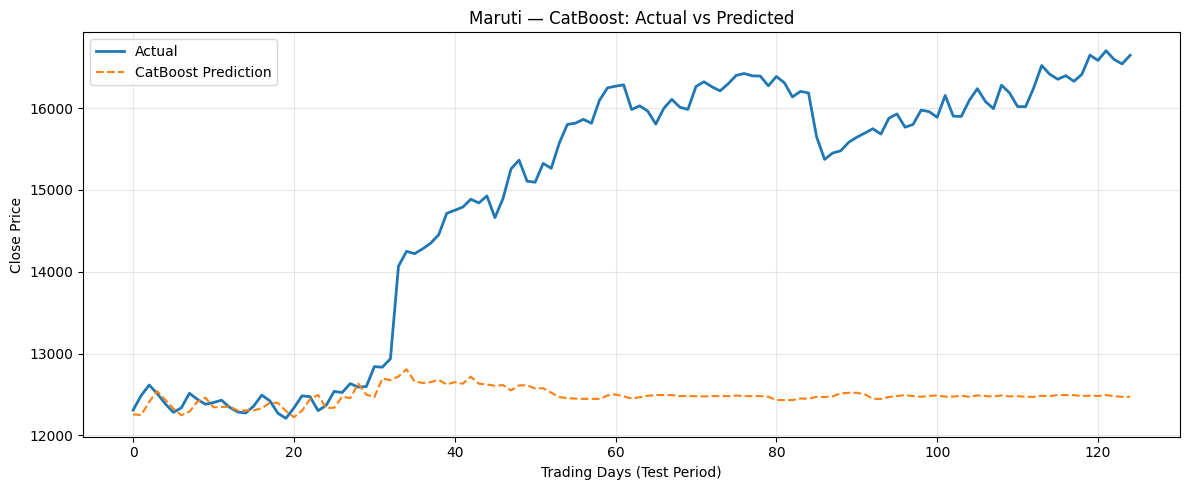

  RMSE=2893.687  MAE=2456.665  MAPE=15.48%  R2=-2.372

[XGBoost] Maruti


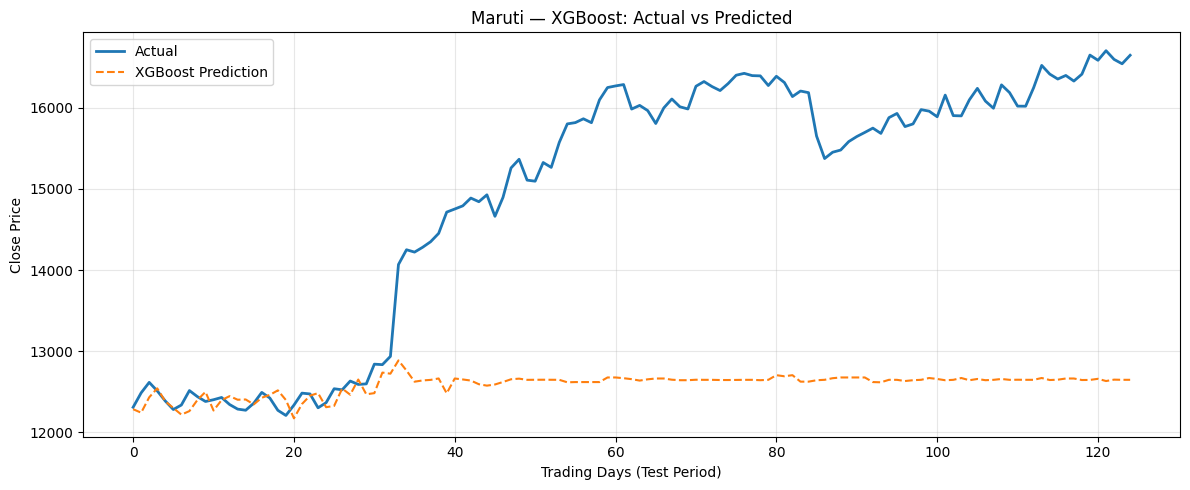

  RMSE=2766.374  MAE=2356.814  MAPE=14.86%  R2=-2.082

[RNN] Maruti


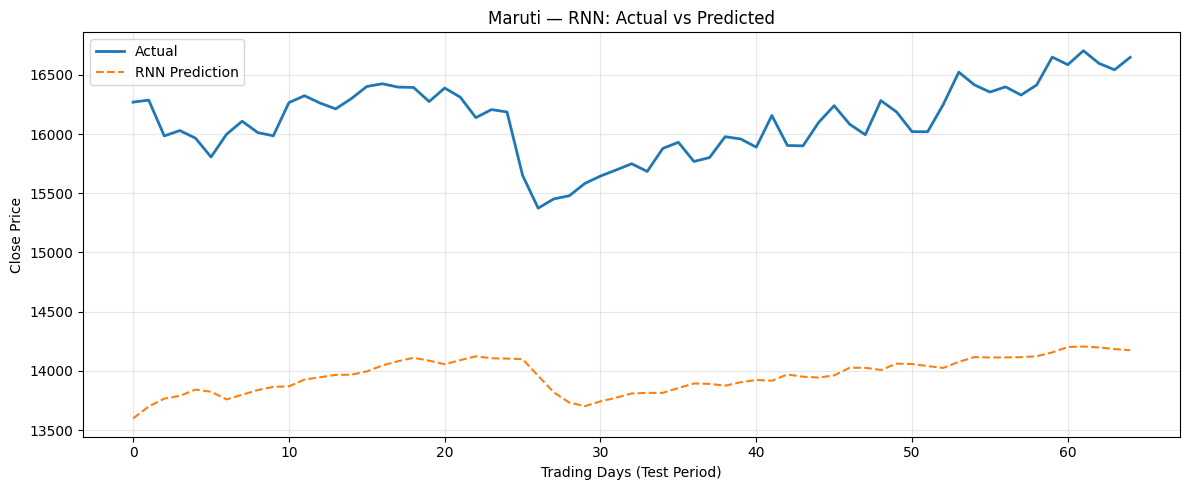

  RMSE=2167.609  MAE=2154.510  MAPE=13.35%  R2=-48.796

[LSTM] Maruti


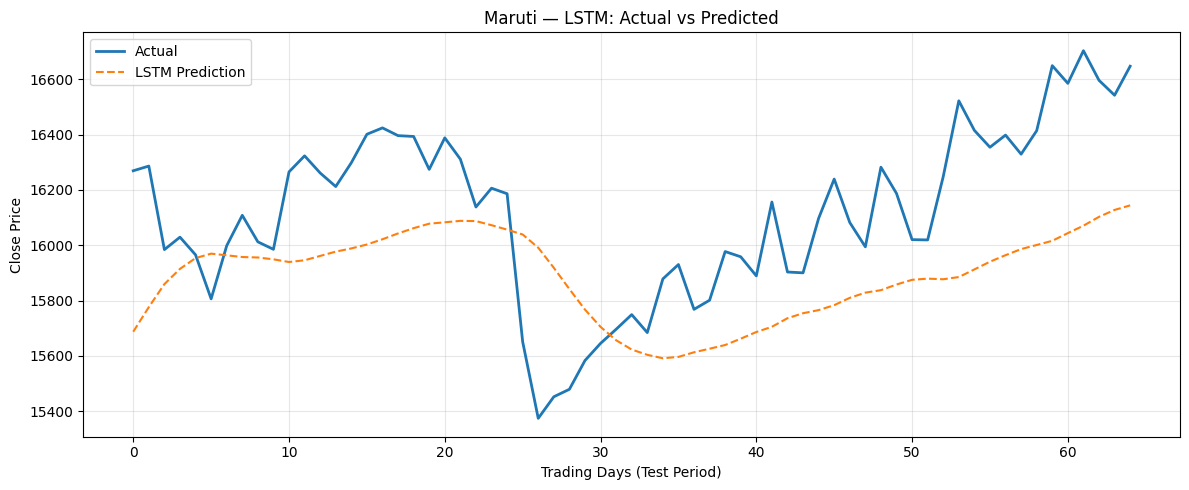

  RMSE=342.080  MAE=297.724  MAPE=1.84%  R2=-0.240

[GRU] Maruti


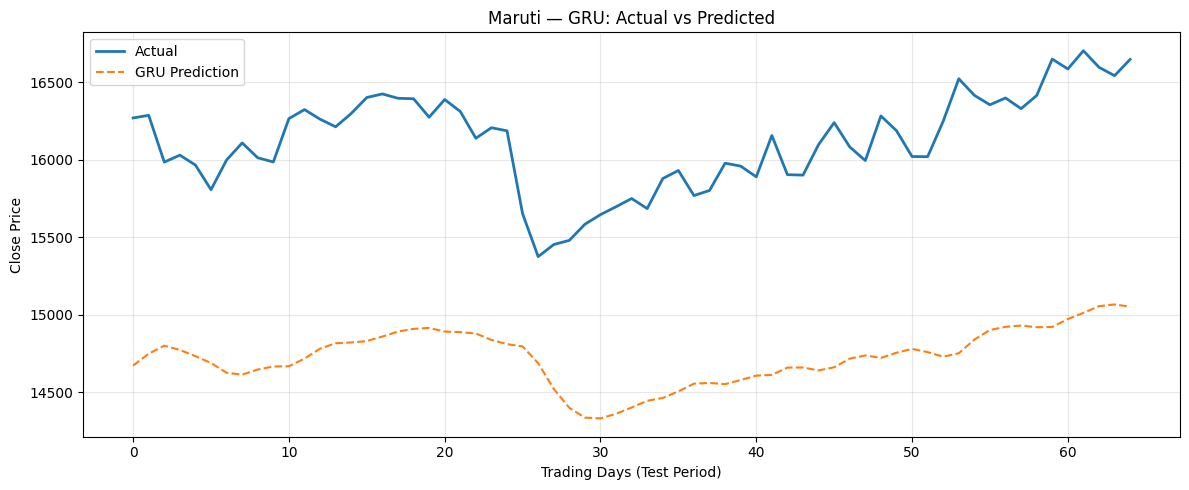

  RMSE=1404.594  MAE=1391.316  MAPE=8.62%  R2=-19.909

######################################################################
STOCK: AbbottIndia
######################################################################
Train: 1110 rows (2021-01-01 to 2025-06-30)
Test : 125 rows (2025-07-01 to 2025-12-30)

[ARIMA baseline] AbbottIndia


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


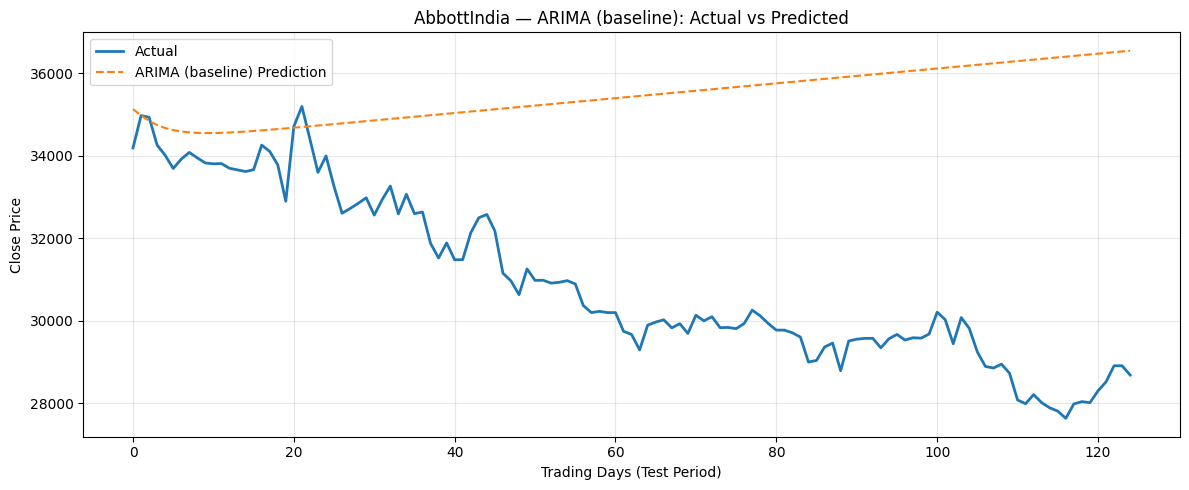

  order=(2, 1, 1)  RMSE=5209.904  MAE=4524.930  MAPE=15.22%  R2=-5.643

[Linear Regression] AbbottIndia


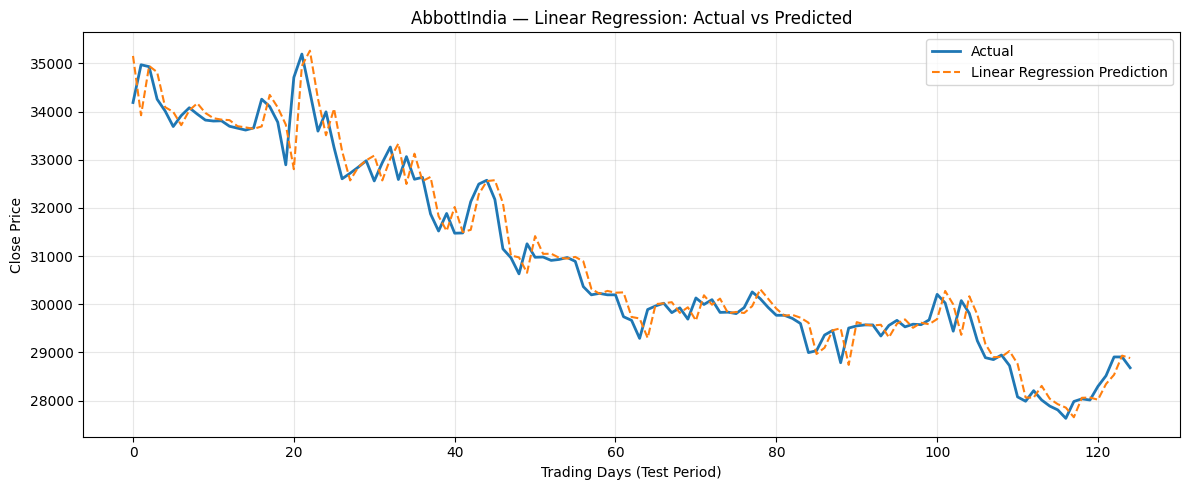

  RMSE=410.758  MAE=288.007  MAPE=0.92%  R2=0.959

[Ridge Regression] AbbottIndia


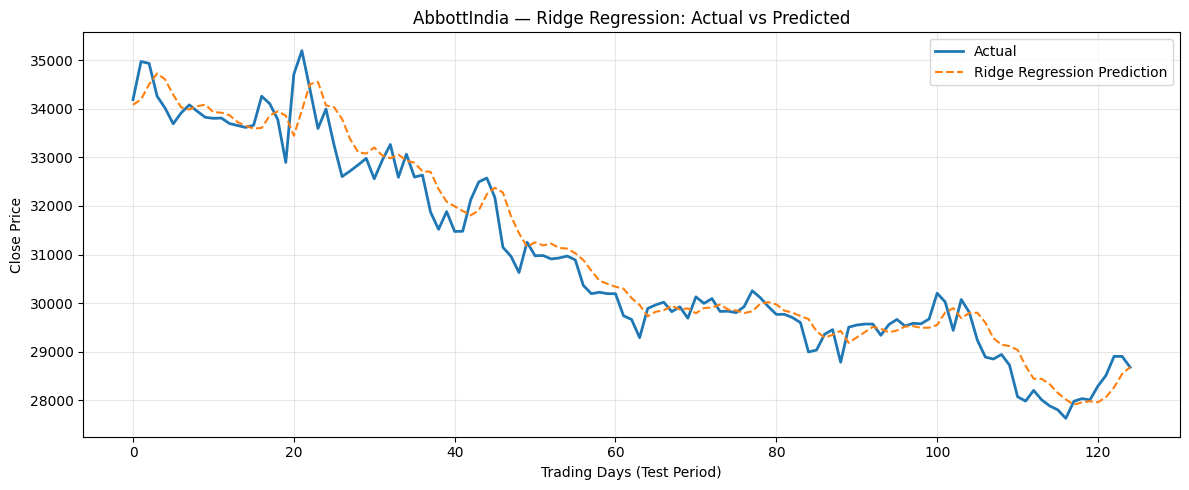

  RMSE=444.783  MAE=339.513  MAPE=1.09%  R2=0.952

[SVR] AbbottIndia


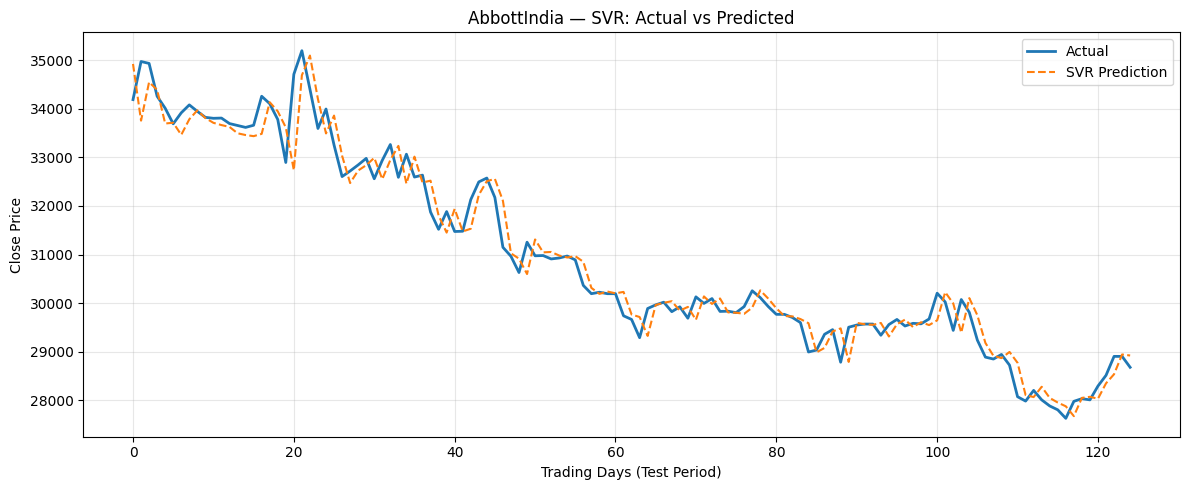

  RMSE=402.274  MAE=286.139  MAPE=0.91%  R2=0.960

[LightGBM] AbbottIndia


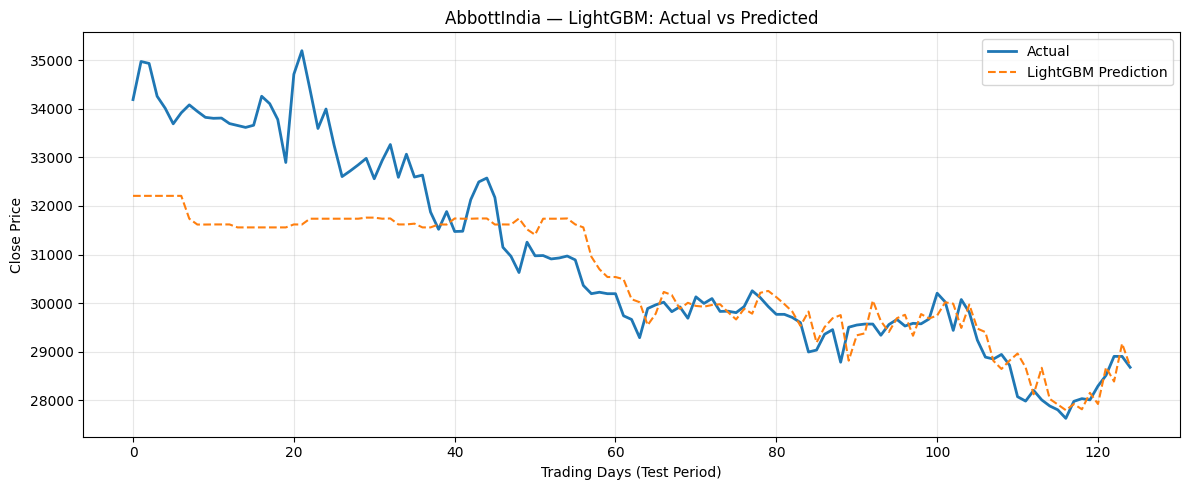

  RMSE=1157.314  MAE=815.560  MAPE=2.51%  R2=0.672

[CatBoost] AbbottIndia


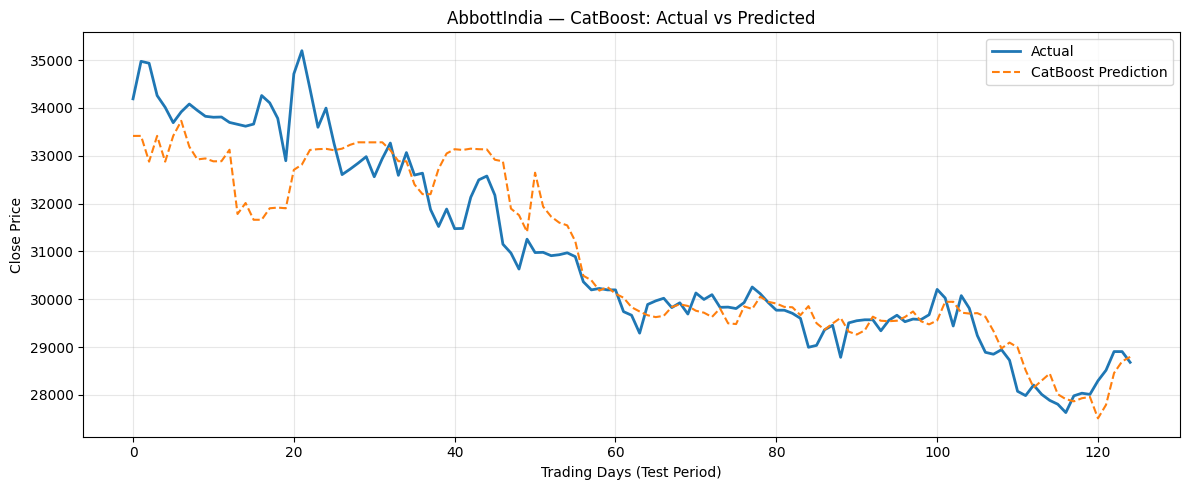

  RMSE=819.809  MAE=581.382  MAPE=1.82%  R2=0.836

[XGBoost] AbbottIndia


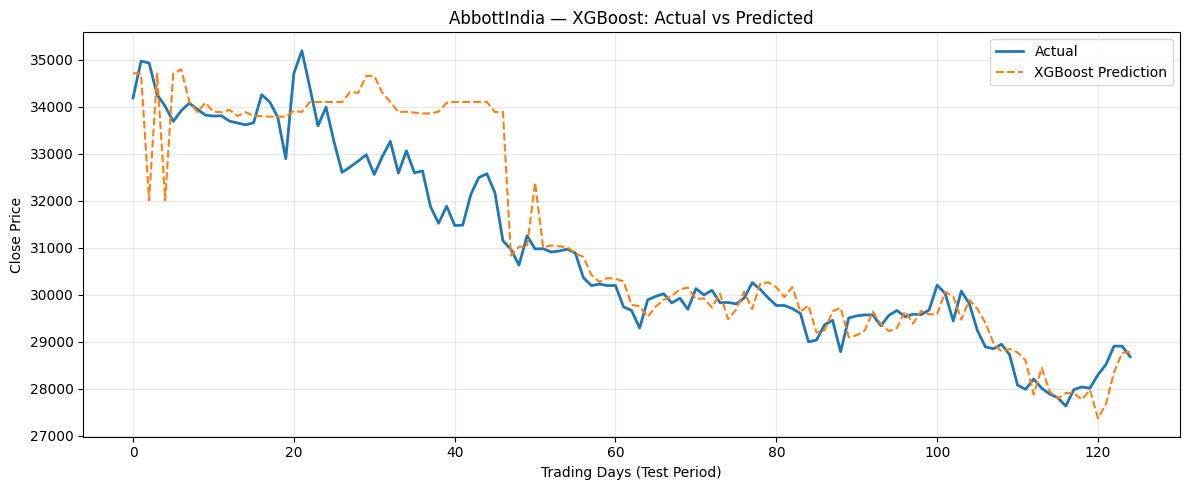

  RMSE=900.025  MAE=595.202  MAPE=1.88%  R2=0.802

[RNN] AbbottIndia


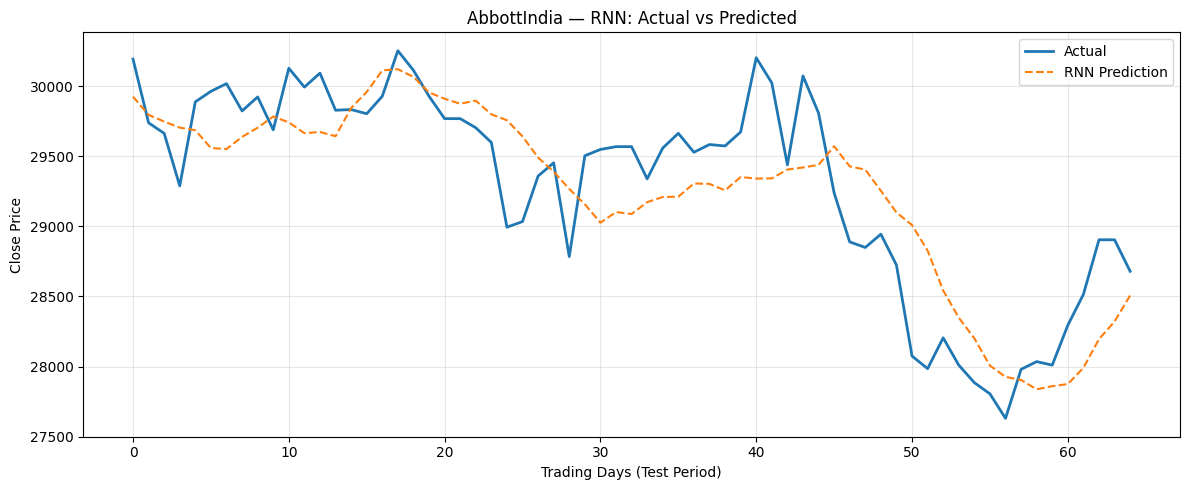

  RMSE=398.497  MAE=334.149  MAPE=1.14%  R2=0.694

[LSTM] AbbottIndia


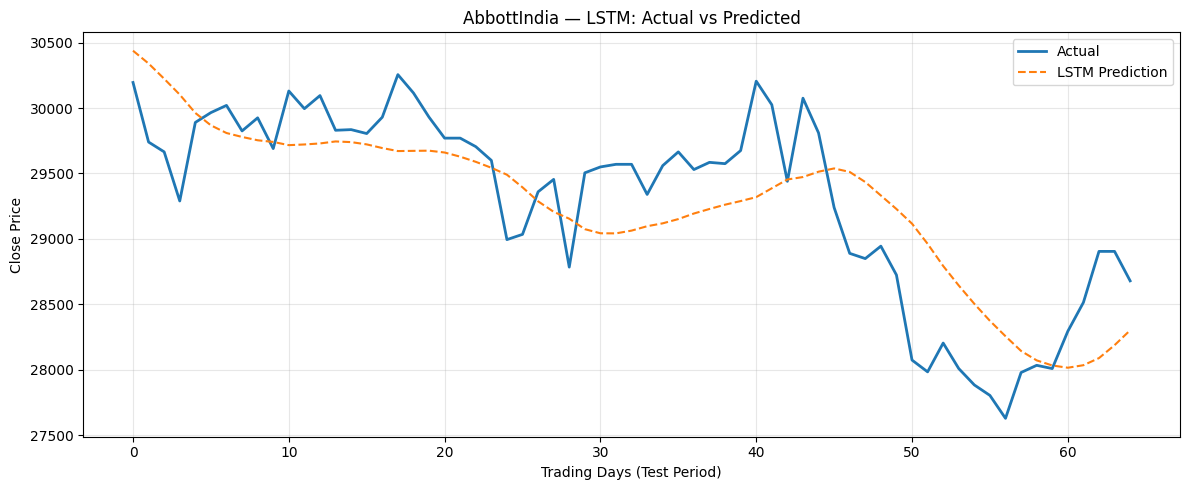

  RMSE=456.737  MAE=384.687  MAPE=1.32%  R2=0.598

[GRU] AbbottIndia


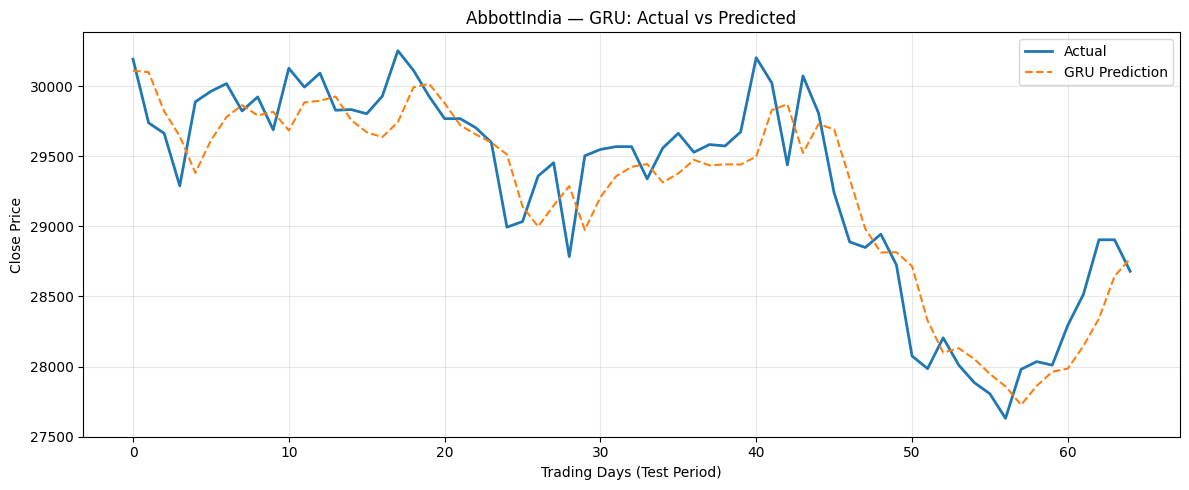

  RMSE=297.546  MAE=244.462  MAPE=0.83%  R2=0.829


In [14]:
for name, df in raw_data.items():
    print("\n" + "#" * 70)
    print(f"STOCK: {name}")
    print("#" * 70)

    df_feat = add_rolling_features(df)
    train_df, test_df = split_by_date(df_feat)
    print(f"Train: {train_df.shape[0]} rows ({train_df.index.min().date()} to {train_df.index.max().date()})")
    print(f"Test : {test_df.shape[0]} rows ({test_df.index.min().date()} to {test_df.index.max().date()})")

    # 1) Baseline
    run_arima_baseline(name, train_df, test_df)

    # 2) Classical / boosted ML models
    run_ml_models(name, df_feat)

    # 3) Deep learning models
    run_dl_models(name, df_feat, epochs=EPOCHS)

## 9. Consolidated Comparison

Combines every (stock, model) result into one table, plots an RMSE
comparison bar chart per stock, and reports the single best model per stock.

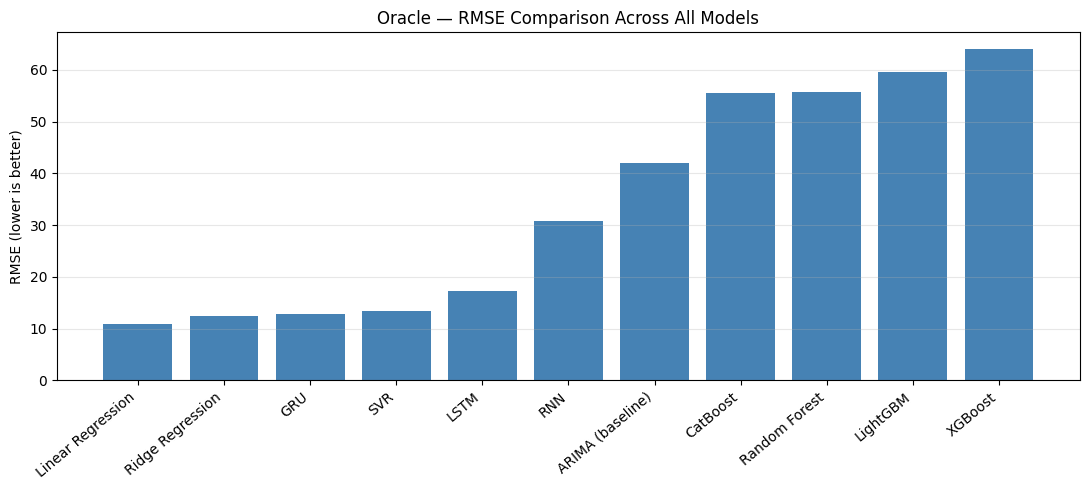

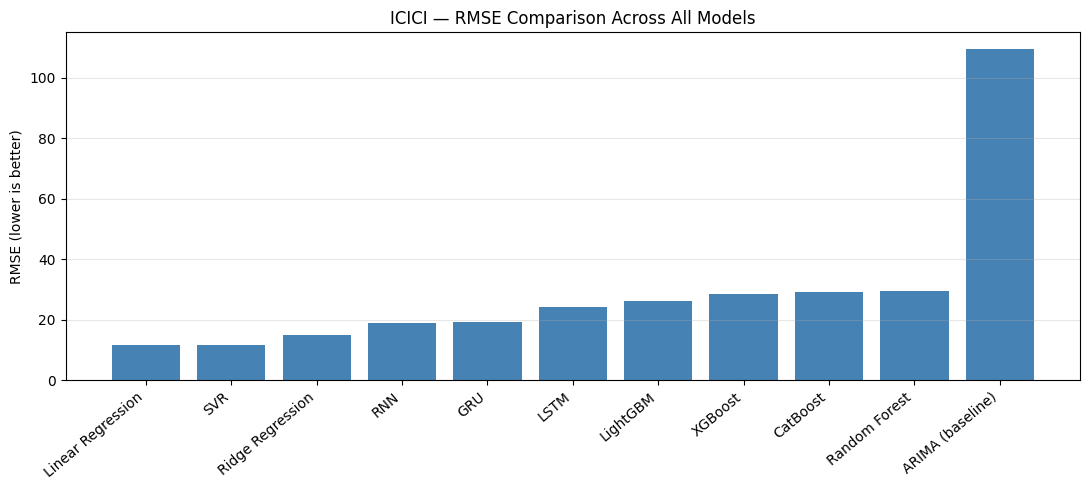

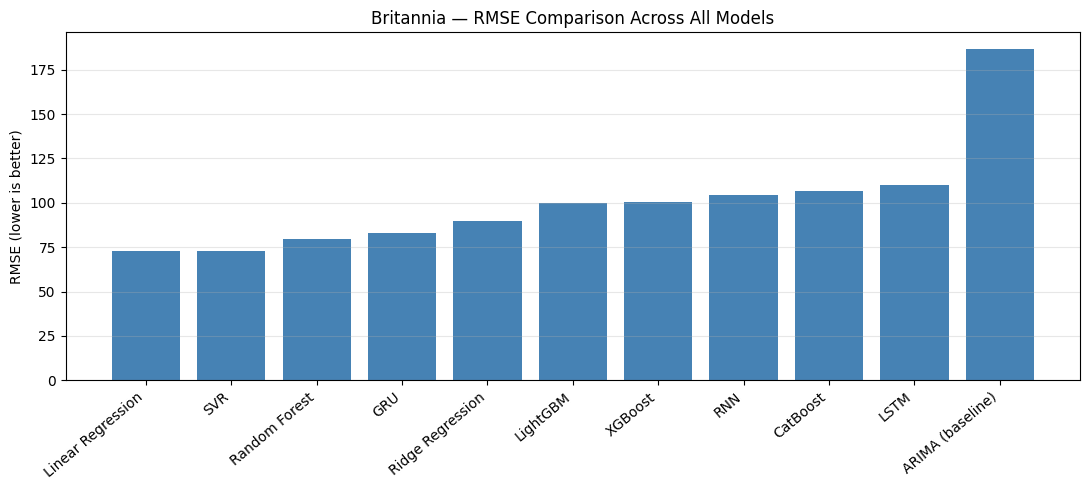

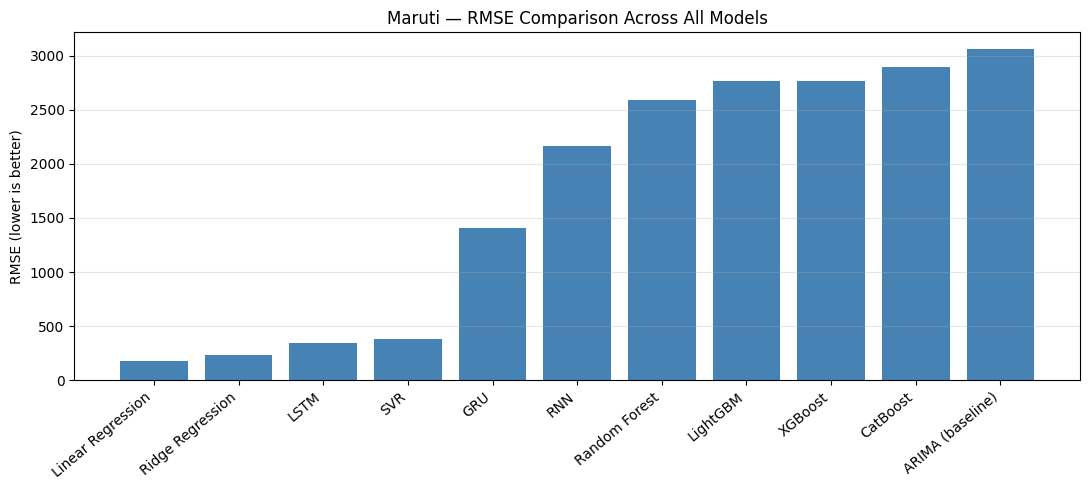

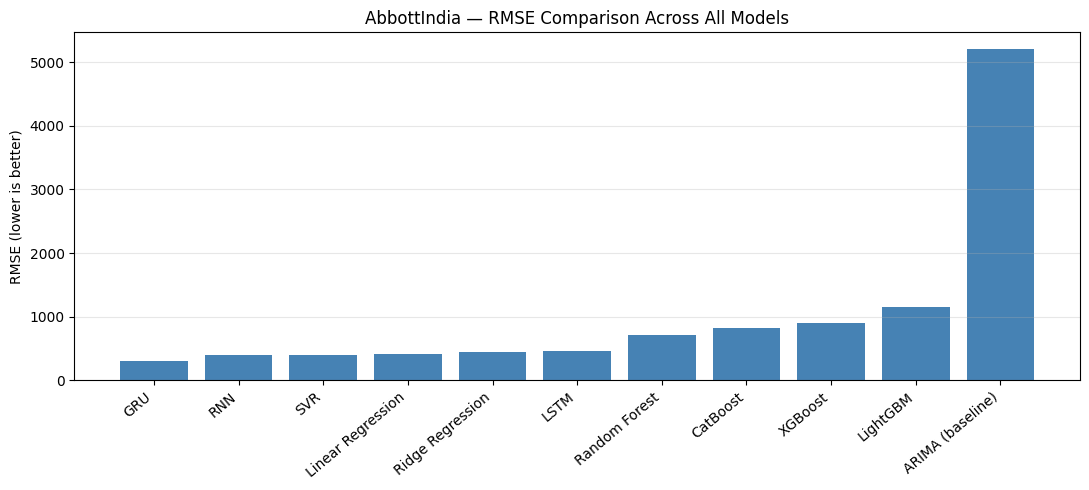

FINAL RESULTS TABLE


,Stock,Model,RMSE,MAE,MAPE,R2
0,Oracle,ARIMA (baseline),41.995,34.575,13.603,-0.423
1,Oracle,Linear Regression,10.790,6.305,2.491,0.906
2,Oracle,Ridge Regression,12.364,7.949,3.229,0.877
3,Oracle,SVR,13.362,8.470,3.258,0.856
4,Oracle,LightGBM,59.624,49.593,18.758,-1.868
5,Oracle,CatBoost,55.418,44.984,16.900,-1.478
6,Oracle,XGBoost,64.036,54.233,20.613,-2.308
7,Oracle,RNN,30.713,24.664,9.405,0.409
8,Oracle,LSTM,17.233,13.644,5.844,0.814
9,Oracle,GRU,12.737,9.931,4.020,0.898


In [27]:
results_df = pd.DataFrame(ALL_RESULTS)
results_df.to_csv(os.path.join(RESULT_DIR, "model_comparison.csv"), index=False)

for name in results_df["Stock"].unique():
    sub = results_df[results_df["Stock"] == name].sort_values("RMSE")
    plt.figure(figsize=(11, 5))
    plt.bar(sub["Model"], sub["RMSE"], color="steelblue")
    plt.xticks(rotation=40, ha="right")
    plt.ylabel("RMSE (lower is better)")
    plt.title(f"{name} — RMSE Comparison Across All Models")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{name}_model_comparison_RMSE.png"), dpi=110)
    plt.show()

best = results_df.loc[results_df.groupby("Stock")["RMSE"].idxmin()].sort_values("Stock")
best.to_csv(os.path.join(RESULT_DIR, "best_model_per_stock.csv"), index=False)

print("FINAL RESULTS TABLE")
results_df.round(3)

In [16]:
print("BEST MODEL PER STOCK")
best.round(3)

BEST MODEL PER STOCK


,Stock,Model,RMSE,MAE,MAPE,R2
49,AbbottIndia,GRU,297.546,244.462,0.835,0.829
21,Britannia,Linear Regression,72.587,54.709,0.940,0.877
11,ICICI,Linear Regression,11.524,8.740,0.627,0.892
31,Maruti,Linear Regression,181.977,127.893,0.860,0.987
1,Oracle,Linear Regression,10.790,6.305,2.491,0.906


All plots are saved under `outputs/plots/` and result tables under
`outputs/results/` (`model_comparison.csv`, `best_model_per_stock.csv`).